In [1]:
import re
import json
import math
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
from docx import Document

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DOCX_PATH = r"C:\Users\GaV\Desktop\Макеты 4 типов таблиц.docx"

CLASS_NAMES = {
    0: "balance_sheet",
    1: "income_statement",
    2: "changes_in_equity",
    3: "cash_flow"
}

CLASS_NAME_TO_ID = {v: k for k, v in CLASS_NAMES.items()}

N_SAMPLES_PER_CLASS = 1500
OUTPUT_DIR = Path(r"C:\Users\GaV\Desktop\output")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [3]:
CLASS_NAME_TO_ID

{'balance_sheet': 0,
 'income_statement': 1,
 'changes_in_equity': 2,
 'cash_flow': 3}

### OCR-конфьюзы рус/англ

In [11]:
RU_EN_CONFUSIONS = {
    "А": "A", "В": "B", "Е": "E", "К": "K", "М": "M", "Н": "H", "О": "O", "Р": "P", "С": "C", "Т": "T", "У": "Y", "Х": "X",
    "а": "a", "е": "e", "о": "o", "р": "p", "с": "c", "у": "y", "х": "x", "к": "k", "м": "m", "т": "t", "в": "b",
    "A": "А", "B": "В", "C": "С", "E": "Е", "H": "Н", "K": "К", "M": "М", "O": "О", "P": "Р", "T": "Т", "X": "Х", "Y": "У",
    "a": "а", "c": "с", "e": "е", "o": "о", "p": "р", "x": "х", "y": "у", "k": "к", "m": "м", "t": "т",
    "0": "О", "1": "l","3":"З","4":"Ч","5":"s","6":"б","7":"1","8":"S", "9":"д"
}

PUNCT_CONFUSIONS = {
    "—": "-",
    "-": "—",
    "(": "",
    ")": "",
    ",": "",
    ".": "",
    "/": "",
    ":": "",
}

### Базовые функции очистки текста

In [4]:
def normalize_ws(text: str) -> str:
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_cell_text(text: str) -> str:
    text = normalize_ws(text)
    return text

def only_digits(text: str) -> str:
    m = re.findall(r"\d+", text)
    return "".join(m)

def safe_float(x, default=0.0):
    try:
        return float(x)
    except:
        return default

### Чтение всех таблиц из docx

In [13]:
def read_docx_tables(docx_path: str):
    doc = Document(docx_path)
    tables = []
    for t_idx, table in enumerate(doc.tables):
        rows = []
        for r_idx, row in enumerate(table.rows):
            cells = [clean_cell_text(cell.text) for cell in row.cells]
            rows.append(cells)
        tables.append({
            "table_idx": t_idx,
            "rows": rows,
            "n_rows": len(rows),
            "n_cols": max((len(r) for r in rows), default=0)
        })
    return tables

tables = read_docx_tables(DOCX_PATH)
len(tables)

4

### Просмотр таблиц и выбор нужных 4 форм

In [5]:
for t in tables:
    print("=" * 120)
    print("table_idx =", t["table_idx"], "rows =", t["n_rows"], "cols =", t["n_cols"])
    for row in t["rows"][:8]:
        print(row)

NameError: name 'tables' is not defined

### Ручная привязка индексов таблиц к 4 классам

In [6]:
def table_to_text(table):
    lines = []
    for row in table["rows"]:
        lines.append(" | ".join([c for c in row if c]))
    return "\n".join(lines)

for t in tables:
    txt = table_to_text(t).upper()
    flags = [
        "БУХГАЛТЕРСКИЙ БАЛАНС" in txt,
        "ОТЧЕТ О ФИНАНСОВЫХ РЕЗУЛЬТАТАХ" in txt,
        "ОТЧЕТ ОБ ИЗМЕНЕНИЯХ КАПИТАЛА" in txt,
        "ОТЧЕТ О ДВИЖЕНИИ ДЕНЕЖНЫХ СРЕДСТВ" in txt,
    ]
    if any(flags):
        print("table_idx =", t["table_idx"], flags)

NameError: name 'tables' is not defined

In [16]:
TABLE_MAP = {
    "balance_sheet": 0,
    "income_statement": 1,
    "changes_in_equity": 2,
    "cash_flow": 3,
}

### Преобразование таблицы в список строк-шаблонов

In [17]:
def infer_row_name_and_code(cells):
    nonempty = [c for c in cells if c]
    if not nonempty:
        return "", ""

    if len(nonempty) == 1:
        txt = nonempty[0]
        m = re.search(r"(.*?)(\d{3,4}(?:\.\.\.)?)\s*$", txt)
        if m:
            return normalize_ws(m.group(1)), normalize_ws(m.group(2))
        return txt, ""

    code = ""
    code_candidates = [c for c in nonempty if re.fullmatch(r"[\d,\.\s]+", c)]
    if code_candidates:
        code = max(code_candidates, key=len)

    name_parts = [c for c in nonempty if c != code]
    name = normalize_ws(" ".join(name_parts))
    code = normalize_ws(code)
    return name, code

def extract_template_rows(table):
    out = []
    for i, cells in enumerate(table["rows"]):
        row_name, row_code = infer_row_name_and_code(cells)
        if not row_name and not row_code:
            continue
        out.append({
            "row_idx": i,
            "row_name": row_name,
            "row_code": row_code,
            "raw_cells": cells
        })
    return out

### Сбор 4 эталонных шаблонов

In [18]:
templates = {}

for class_name, table_idx in TABLE_MAP.items():
    if table_idx is None:
        continue
    table = [t for t in tables if t["table_idx"] == table_idx][0]
    templates[class_name] = extract_template_rows(table)

for class_name, rows in templates.items():
    print(class_name, len(rows))
    print(rows[:5])
    print()

balance_sheet 41
[{'row_idx': 0, 'row_name': 'Наименование показателя Код', 'row_code': '', 'raw_cells': ['Наименование показателя', 'Код']}, {'row_idx': 1, 'row_name': 'БУХГАЛТЕРСКИЙ БАЛАНС', 'row_code': '1000', 'raw_cells': ['БУХГАЛТЕРСКИЙ БАЛАНС', '1000']}, {'row_idx': 2, 'row_name': 'Итого внеоборотных активов', 'row_code': '1100', 'raw_cells': ['Итого внеоборотных активов', '1100']}, {'row_idx': 3, 'row_name': 'Гудвил', 'row_code': '1105', 'raw_cells': ['Гудвил', '1105']}, {'row_idx': 4, 'row_name': 'Нематериальные активы', 'row_code': '1110', 'raw_cells': ['Нематериальные активы', '1110']}]

income_statement 25
[{'row_idx': 0, 'row_name': 'ОТЧЕТ О ФИНАНСОВЫХ РЕЗУЛЬТАТАХ', 'row_code': '2000', 'raw_cells': ['ОТЧЕТ О ФИНАНСОВЫХ РЕЗУЛЬТАТАХ', '2000']}, {'row_idx': 1, 'row_name': 'Выручка', 'row_code': '2110', 'raw_cells': ['Выручка', '2110']}, {'row_idx': 2, 'row_name': 'Себестоимость продаж', 'row_code': '2120', 'raw_cells': ['Себестоимость продаж', '2120']}, {'row_idx': 3, 'row_nam

### Функции структурных признаков строки

In [7]:
TOTAL_PATTERNS = [
    "итого", "всего", "сальдо", "баланс", "чистая прибыль",
    "совокупный финансовый результат", "величина капитала"
]

def is_upper_like(text: str) -> int:
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0
    upper = sum(ch.isupper() for ch in letters)
    return int(upper / len(letters) > 0.8)

def has_digits(text: str) -> int:
    return int(bool(re.search(r"\d", text)))

def is_total_like(text: str) -> int:
    low = text.lower()
    return int(any(p in low for p in TOTAL_PATTERNS))

def indentation_score(text: str) -> float:
    n_lead = len(text) - len(text.lstrip())
    return float(min(n_lead, 20)) / 20.0

def row_text_stats(text: str):
    return {
        "text_len": len(text),
        "num_words": len(text.split()) if text else 0,
        "num_digits_text": len(re.findall(r"\d", text)),
        "has_parentheses": int(("(" in text) or (")" in text)),
        "has_slash": int("/" in text),
        "is_upper_like": is_upper_like(text),
        "is_total_like": is_total_like(text),
        "has_digits": has_digits(text)
    }

###  OCR-аугментация текста

In [8]:
def random_delete_char(text, p=0.01):
    out = []
    for ch in text:
        if random.random() > p:
            out.append(ch)
    return "".join(out)

def random_insert_space(text, p=0.01):
    out = []
    for ch in text:
        out.append(ch)
        if ch.isalpha() and random.random() < p:
            out.append(" ")
    return "".join(out)

def random_char_confusion(text, p=0.03):
    out = []
    for ch in text:
        if ch in RU_EN_CONFUSIONS and random.random() < p:
            out.append(RU_EN_CONFUSIONS[ch])
        elif ch in PUNCT_CONFUSIONS and random.random() < p:
            out.append(PUNCT_CONFUSIONS[ch])
        else:
            out.append(ch)
    return "".join(out)

def random_case_noise(text, p=0.01):
    out = []
    for ch in text:
        if ch.isalpha() and random.random() < p:
            out.append(ch.swapcase())
        else:
            out.append(ch)
    return "".join(out)

def augment_text_ocr(text: str,
                     p_confuse=0.03,
                     p_delete=0.01,
                     p_space=0.01,
                     p_case=0.01):
    x = text
    x = random_char_confusion(x, p=p_confuse)
    x = random_delete_char(x, p=p_delete)
    x = random_insert_space(x, p=p_space)
    x = random_case_noise(x, p=p_case)
    x = normalize_ws(x)
    return x

#### Аугментация геометрии и crop по строкам

In [10]:
def jitter(v, sigma=0.02, low=0.0, high=1.0):
    x = v + np.random.normal(0, sigma)
    return float(np.clip(x, low, high))

def synthetic_bbox_features(row_name, row_code, row_pos, total_rows):
    base_x_left = 0.08 + min(indentation_score(row_name) * 0.08, 0.08)
    base_x_right = 0.92
    if row_code:
        base_x_right = 0.96

    x_left = jitter(base_x_left, sigma=0.05)
    x_right = jitter(base_x_right, sigma=0.05)
    width = max(0.05, x_right - x_left)
    y_center = (row_pos + 0.5) / max(total_rows, 1)
    row_height = jitter(1.0 / max(total_rows, 1), sigma=0.01, low=0.005, high=0.3)

    return {
        "x_left": x_left,
        "x_right": x_right,
        "width": width,
        "y_center": y_center,
        "row_height": row_height
    }

def crop_rows(rows, max_drop_ratio=0.3):
    n = len(rows)
    if n <= 4:
        return rows

    max_drop = max(1, int(n * max_drop_ratio))
    drop_top = random.randint(0, max_drop)
    drop_bottom = random.randint(0, max_drop)

    if drop_top + drop_bottom >= n - 2:
        drop_top = min(drop_top, max(0, n - 3))
        drop_bottom = min(drop_bottom, max(0, n - 2 - drop_top))

    return rows[drop_top:n-drop_bottom]

### Генерация одного синтетического экземпляра таблицы и Генерация всего датасета в “длинном” формате

In [22]:
def generate_one_sample(template_rows, class_name):
    rows = deepcopy(template_rows)
    rows = crop_rows(rows, max_drop_ratio=0.4)

    records = []
    total_rows = len(rows)

    for new_pos, row in enumerate(rows):
        row_name = row["row_name"]
        row_code = row["row_code"]

        row_name_noisy = augment_text_ocr(
            row_name,
            p_confuse=np.random.uniform(0.0, 0.4),
            p_delete=np.random.uniform(0.0, 0.4),
            p_space=np.random.uniform(0.0, 0.4),
            p_case=np.random.uniform(0.0, 0.4)
        )

        #if random.random() < 0.3:
        #    row_code_noisy = re.sub(r"\d", 
        #                            lambda m: str((int(m.group(0)) + random.randint(1, 8)) % 10) if random.random() < 0.3 else m.group(0), 
        #                            row_code)
        #else:
        #    row_code_noisy = row_code
        row_code_noisy = str(row_code)
            
        row_code_noisy = augment_text_ocr(
            row_code_noisy,
            p_confuse=np.random.uniform(0.0, 0.2),
            p_delete=np.random.uniform(0.0, 0.2),
            p_space=np.random.uniform(0.0, 0.5),
            p_case=0
        )
        

        geom = synthetic_bbox_features(row_name_noisy, row_code_noisy, new_pos, total_rows)
        stats = row_text_stats(row_name_noisy)

        rec = {
            "class_name": class_name,
            "class_id": CLASS_NAME_TO_ID[class_name],
            "seq_pos": new_pos,
            "seq_len": total_rows,
            "row_text": row_name_noisy,
            "row_code": row_code_noisy,
            "code_len": len(row_code_noisy),
            "num_digits_code": len(re.findall(r"\d", row_code_noisy)),
            **geom,
            **stats
        }
        records.append(rec)

    return records

global_sample_id = 0
all_records = []

for class_name, template_rows in templates.items():
    for _ in range(N_SAMPLES_PER_CLASS):
        sample_rows = generate_one_sample(template_rows, class_name)
        for row in sample_rows:
            #row["sample_id"] = f"{class_name}_{sample_id:05d}"
            row["sample_id"] = global_sample_id
            all_records.append(row)
        global_sample_id += 1

df_long = pd.DataFrame(all_records)
df_long.shape

(124837, 22)

In [23]:
df_long.head(100)

,class_name,class_id,seq_pos,seq_len,row_text,row_code,code_len,num_digits_code,x_left,x_right,...,row_height,text_len,num_words,num_digits_text,has_parentheses,has_slash,is_upper_like,is_total_like,has_digits,sample_id
0,balance_sheet,0,0,38,д в и,1105,4,4,0.093952,1.000000,...,0.020507,5,3,0,0,0,0,0,0,0
1,balance_sheet,0,1,38,НеМАериaл ьнЫе акТВы,1110,4,4,0.053742,0.914599,...,0.012193,20,3,0,0,0,0,0,0,0
2,balance_sheet,0,2,38,емАте и aЛы пО и к ОЫе АКтиВы,1l30,4,3,0.049987,1.000000,...,0.029226,29,8,0,0,0,0,0,0,0
3,balance_sheet,0,3,38,Ма teр иал ьн ые поиковые ак tивы,110,3,3,0.048222,0.970443,...,0.006719,33,8,0,0,0,0,0,0,0
4,balance_sheet,0,4,38,Ос Нов н ые СрДС t вa,1150,4,4,0.029546,0.880835,...,0.034053,21,7,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,balance_sheet,0,2,17,длгоcро чныа иb ы к пОДАже,121,3,3,0.086749,0.964114,...,0.069478,26,6,0,0,0,0,0,0,3
96,balance_sheet,0,3,17,Aога до Бав н yю Ctи mст ьп о Пp и o брT ннм Е...,1220,4,4,0.125991,0.975693,...,0.042005,53,18,0,0,0,0,0,0,3
97,balance_sheet,0,4,17,Дбиторcкая зaдоЛжeнность,2З0,3,2,0.000000,0.958266,...,0.061166,24,2,0,0,0,0,0,0,3
98,balance_sheet,0,5,17,и нСов ы влОЖеН (a ИСкЛюEНЕ МднЕжнЫЭ квВАЛН O В),1240,4,4,0.195486,0.926805,...,0.070495,48,10,0,1,0,0,0,0,3


### Символьный словарь для BiLSTM по тексту строк

In [24]:
SPECIAL_TOKENS = ["<PAD>", "<UNK>"]

all_texts = df_long["row_text"].fillna("").tolist() + df_long["row_code"].fillna("").tolist()
charset = sorted(set("".join(all_texts)))
itos = SPECIAL_TOKENS + charset
stoi = {ch: i for i, ch in enumerate(itos)}

def encode_text(text, stoi, max_len=128):
    ids = [stoi.get(ch, stoi["<UNK>"]) for ch in text[:max_len]]
    length = len(ids)
    if length < max_len:
        ids = ids + [stoi["<PAD>"]] * (max_len - length)
    return ids, length

print(len(stoi))
print(list(itos))

110
['<PAD>', '<UNK>', ' ', '(', ')', ',', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', 'A', 'B', 'C', 'E', 'H', 'K', 'L', 'M', 'O', 'P', 'S', 'T', 'X', 'Y', 'a', 'b', 'c', 'e', 'h', 'k', 'l', 'm', 'o', 'p', 's', 't', 'x', 'y', 'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ы', 'Ь', 'Э', 'Ю', 'Я', 'а', 'б', 'в', 'г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ы', 'ь', 'э', 'ю', 'я', '–', '…']


### Табличные признаки строки и Упаковка в последовательности по sample_id

In [25]:
NUMERIC_FEATURES = [
    "seq_pos", "seq_len",
    "code_len", "num_digits_code",
    "x_left", "x_right", "width", "y_center", "row_height",
    "text_len", "num_words", "num_digits_text",
    "has_parentheses", "has_slash", "is_upper_like",
    "is_total_like", "has_digits"
]

def build_row_features(row, stoi, text_max_len=128, code_max_len=16):
    text_ids, text_len = encode_text(row["row_text"], stoi, max_len=text_max_len)
    code_ids, code_len_real = encode_text(row["row_code"], stoi, max_len=code_max_len)

    numeric = [row[col] for col in NUMERIC_FEATURES]
    return {
        "numeric": np.array(numeric, dtype=np.float32),
        "text_ids": np.array(text_ids, dtype=np.int64),
        "text_len": int(text_len),
        "code_ids": np.array(code_ids, dtype=np.int64),
        "code_len_real": int(code_len_real)
    }

grouped = []
for sample_id, g in df_long.sort_values(["sample_id", "seq_pos"]).groupby("sample_id"):
    rows = []
    for _, row in g.iterrows():
        feats = build_row_features(row, stoi)
        rows.append(feats)

    grouped.append({
        "sample_id": sample_id,
        "class_id": int(g["class_id"].iloc[0]),
        "class_name": g["class_name"].iloc[0],
        "rows": rows,
        "seq_len": len(rows)
    })

len(grouped), grouped[0]["class_name"]

(6000, 'balance_sheet')

### Подготовка numpy-структур для датасета

In [ ]:
def stack_sample(sample):
    numeric = np.stack([r["numeric"] for r in sample["rows"]], axis=0)
    text_ids = np.stack([r["text_ids"] for r in sample["rows"]], axis=0)
    text_len = np.array([r["text_len"] for r in sample["rows"]], dtype=np.int64)
    code_ids = np.stack([r["code_ids"] for r in sample["rows"]], axis=0)
    code_len = np.array([r["code_len_real"] for r in sample["rows"]], dtype=np.int64)

    return {
        "sample_id": sample["sample_id"],
        "class_id": sample["class_id"],
        "class_name": sample["class_name"],
        "seq_len": sample["seq_len"],
        "numeric": numeric,
        "text_ids": text_ids,
        "text_len": text_len,
        "code_ids": code_ids,
        "code_len": code_len
    }

dataset = [stack_sample(s) for s in grouped]
dataset[0]

### Cохранение метаданных и long-format CSV

In [27]:
df_long.to_csv(OUTPUT_DIR / "synthetic_table_rows_long.csv", index=False, encoding="utf-8")

meta = {
    "class_names": CLASS_NAMES,
    "numeric_features": NUMERIC_FEATURES,
    "vocab_size": len(stoi),
    "stoi": stoi
}

with open(OUTPUT_DIR / "synthetic_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

### Cохранение train-ready pickle

In [28]:
import pickle

with open(OUTPUT_DIR / "synthetic_bilstm_dataset.pkl", "wb") as f:
    pickle.dump(dataset, f)

### PyTorch Dataset. 
Для BiLSTM важно корректно обрабатывать переменную длину последовательности таблицы, поэтому в collate_fn надо паддить по числу строк, а затем использовать pack_padded_sequence на уровне table-sequence. Такой подход считается стандартным для RNN/LSTM с разной длиной последовательностей.

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader

class TableSequenceDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "sample_id": s["sample_id"],
            "class_id": s["class_id"],
            "seq_len": s["seq_len"],
            "numeric": torch.tensor(s["numeric"], dtype=torch.float32),
            "text_ids": torch.tensor(s["text_ids"], dtype=torch.long),
            "text_len": torch.tensor(s["text_len"], dtype=torch.long),
            "code_ids": torch.tensor(s["code_ids"], dtype=torch.long),
            "code_len": torch.tensor(s["code_len"], dtype=torch.long),
        }

def collate_table_batch(batch):
    batch = sorted(batch, key=lambda x: x["seq_len"], reverse=True)
    B = len(batch)
    T = max(x["seq_len"] for x in batch)

    num_dim = batch[0]["numeric"].shape[-1]
    text_max_len = batch[0]["text_ids"].shape[-1]
    code_max_len = batch[0]["code_ids"].shape[-1]

    numeric = torch.zeros(B, T, num_dim, dtype=torch.float32)
    text_ids = torch.zeros(B, T, text_max_len, dtype=torch.long)
    text_len = torch.zeros(B, T, dtype=torch.long)
    code_ids = torch.zeros(B, T, code_max_len, dtype=torch.long)
    code_len = torch.zeros(B, T, dtype=torch.long)
    seq_lens = torch.zeros(B, dtype=torch.long)
    labels = torch.zeros(B, dtype=torch.long)

    for i, item in enumerate(batch):
        t = item["seq_len"]
        seq_lens[i] = t
        labels[i] = item["class_id"]
        numeric[i, :t] = item["numeric"]
        text_ids[i, :t] = item["text_ids"]
        text_len[i, :t] = item["text_len"]
        code_ids[i, :t] = item["code_ids"]
        code_len[i, :t] = item["code_len"]

    return {
        "numeric": numeric,
        "text_ids": text_ids,
        "text_len": text_len,
        "code_ids": code_ids,
        "code_len": code_len,
        "seq_lens": seq_lens,
        "labels": labels
    }

torch_dataset = TableSequenceDataset(dataset)
loader = DataLoader(torch_dataset, batch_size=8, shuffle=True, collate_fn=collate_table_batch)

batch = next(iter(loader))
for k, v in batch.items():
    print(k, tuple(v.shape))

numeric (8, 34, 17)
text_ids (8, 34, 128)
text_len (8, 34)
code_ids (8, 34, 16)
code_len (8, 34)
seq_lens (8,)
labels (8,)


In [30]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader

all_indices = np.arange(len(dataset))
all_labels = np.array([x["class_id"] for x in dataset])

train_idx, valid_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels
)

train_samples = [dataset[i] for i in train_idx]
valid_samples = [dataset[i] for i in valid_idx]

print(len(train_samples), len(valid_samples))


train_ds = TableSequenceDataset(train_samples)
valid_ds = TableSequenceDataset(valid_samples)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_table_batch
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_table_batch
)

4800 1200


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device)
    return out

device

device(type='cpu')

### Посимвольный encoder строки

In [32]:
import torch.nn as nn
import torch.nn.functional as F

class CharBiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=64, num_layers=1, pad_idx=0, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.output_dim = hidden_dim * 2
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        lengths = lengths.clamp(min=1)
        emb = self.dropout(self.embedding(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)

        if self.lstm.bidirectional:
            out = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        else:
            out = h_n[-1]

        return out

In [33]:
class RowEncoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        char_emb_dim=64,
        char_hidden_dim=64,
        code_emb_dim=32,
        code_hidden_dim=32,
        row_hidden_dim=128,
        pad_idx=0,
        dropout=0.2
    ):
        super().__init__()

        self.text_encoder = CharBiLSTMEncoder(
            vocab_size=vocab_size,
            emb_dim=char_emb_dim,
            hidden_dim=char_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout
        )

        self.code_encoder = CharBiLSTMEncoder(
            vocab_size=vocab_size,
            emb_dim=code_emb_dim,
            hidden_dim=code_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout
        )

        row_in_dim = self.text_encoder.output_dim + self.code_encoder.output_dim + num_numeric_features
        row_in_dim = self.text_encoder.output_dim + num_numeric_features

        self.row_mlp = nn.Sequential(
            nn.Linear(row_in_dim, row_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(row_hidden_dim, row_hidden_dim),
            nn.ReLU()
        )

        self.output_dim = row_hidden_dim

    def forward(self, text_ids, text_len, code_ids, code_len, numeric):
        bsz, T, L_text = text_ids.shape
        _, _, L_code = code_ids.shape
        num_dim = numeric.shape[-1]

        text_ids_f = text_ids.reshape(bsz * T, L_text)
        text_len_f = text_len.reshape(bsz * T)

        code_ids_f = code_ids.reshape(bsz * T, L_code)
        code_len_f = code_len.reshape(bsz * T)

        numeric_f = numeric.reshape(bsz * T, num_dim)

        text_vec = self.text_encoder(text_ids_f, text_len_f)
        code_vec = self.code_encoder(code_ids_f, code_len_f)

        row_vec = torch.cat([text_vec, code_vec, numeric_f], dim=-1)
        row_vec = torch.cat([text_vec, numeric_f], dim=-1)
        row_vec = self.row_mlp(row_vec)
        row_vec = row_vec.reshape(bsz, T, -1)

        return row_vec

In [34]:
class TableBiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        num_classes=4,
        row_hidden_dim=128,
        table_hidden_dim=128,
        pad_idx=0,
        dropout=0.2
    ):
        super().__init__()

        self.row_encoder = RowEncoder(
            vocab_size=vocab_size,
            num_numeric_features=num_numeric_features,
            row_hidden_dim=row_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout
        )

        self.table_lstm = nn.LSTM(
            input_size=self.row_encoder.output_dim,
            hidden_size=table_hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(table_hidden_dim * 2, table_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(table_hidden_dim, num_classes)
        )

    def forward(self, batch):
        row_vec = self.row_encoder(
            text_ids=batch["text_ids"],
            text_len=batch["text_len"],
            code_ids=batch["code_ids"],
            code_len=batch["code_len"],
            numeric=batch["numeric"]
        )

        packed = nn.utils.rnn.pack_padded_sequence(
            row_vec,
            batch["seq_lens"].cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h_n, _) = self.table_lstm(packed)

        table_vec = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        logits = self.classifier(self.dropout(table_vec))
        return logits


In [35]:
PAD_IDX = stoi["<PAD>"]

model = TableBiLSTMClassifier(
    vocab_size=len(stoi),
    num_numeric_features=len(NUMERIC_FEATURES),
    num_classes=4,
    row_hidden_dim=128,
    table_hidden_dim=128,
    pad_idx=PAD_IDX,
    dropout=0.2
).to(device)

In [36]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"{name:20s} {n}")
    for subname, submodule in module.named_children():
        n = sum(p.numel() for p in submodule.parameters())
        print(f"   {subname:20s} {n}")
    print(' '*50)

print('-'*50)
print("Total params:", total_params)
print("Trainable params:", trainable_params)


row_encoder          129216
   text_encoder         73600
   code_encoder         20416
   row_mlp              35200
                                                  
table_lstm           264192
                                                  
dropout              0
                                                  
classifier           33412
   0                    32896
   1                    0
   2                    0
   3                    516
                                                  
--------------------------------------------------
Total params: 426820
Trainable params: 426820


In [37]:
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in tqdm(loader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)

        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, batch["labels"])
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * batch["labels"].size(0)
        total_correct += (preds == batch["labels"]).sum().item()
        total_count += batch["labels"].size(0)

    return total_loss / total_count, total_correct / total_count

In [38]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    all_preds = []
    all_targets = []

    for batch in tqdm(loader, desc="valid", leave=False):
        batch = move_batch_to_device(batch, device)

        logits = model(batch)
        loss = criterion(logits, batch["labels"])

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * batch["labels"].size(0)
        total_correct += (preds == batch["labels"]).sum().item()
        total_count += batch["labels"].size(0)

        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(batch["labels"].cpu().tolist())

    return total_loss / total_count, total_correct / total_count, all_preds, all_targets

In [ ]:
NUM_EPOCHS = 4
history = []
best_val_acc = -1.0
best_path = OUTPUT_DIR / "char_bilstm_table_bilstm_best.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_preds, val_targets = evaluate(model, valid_loader, criterion, device)

    scheduler.step(val_acc)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.6f}"
    )

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)

In [40]:
torch.save(model.state_dict(), best_path)

In [41]:
hist_df = pd.DataFrame(history)
hist_df

,epoch,train_loss,train_acc,val_loss,val_acc,lr
0,1,0.175734,0.930000,0.000377,1.0,0.0030
1,2,0.010009,0.997292,0.000006,1.0,0.0030
2,3,0.001498,0.999375,0.000004,1.0,0.0030
3,4,0.000029,1.000000,0.000001,1.0,0.0015


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

id_to_class = {v: k for k, v in CLASS_NAME_TO_ID.items()}

print(classification_report(
    val_targets,
    val_preds,
    target_names=[id_to_class[i] for i in range(4)],
    digits=4
))

cm = confusion_matrix(val_targets, val_preds)
cm

In [359]:
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{id_to_class[i]}" for i in range(4)],
    columns=[f"pred_{id_to_class[i]}" for i in range(4)]
)
cm_df

,pred_balance_sheet,pred_income_statement,pred_changes_in_equity,pred_cash_flow
true_balance_sheet,300,0,0,0
true_income_statement,0,300,0,0
true_changes_in_equity,0,0,300,0
true_cash_flow,0,0,0,300


In [43]:
best_model = TableBiLSTMClassifier(
    vocab_size=len(stoi),
    num_numeric_features=len(NUMERIC_FEATURES),
    num_classes=4,
    row_hidden_dim=128,
    table_hidden_dim=128,
    pad_idx=PAD_IDX,
    dropout=0.2
).to(device)

best_model.load_state_dict(torch.load(best_path, map_location=device))
best_model.eval()

TableBiLSTMClassifier(
  (row_encoder): RowEncoder(
    (text_encoder): CharBiLSTMEncoder(
      (embedding): Embedding(110, 64, padding_idx=0)
      (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (code_encoder): CharBiLSTMEncoder(
      (embedding): Embedding(110, 32, padding_idx=0)
      (lstm): LSTM(32, 32, batch_first=True, bidirectional=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (row_mlp): Sequential(
      (0): Linear(in_features=145, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): ReLU()
    )
  )
  (table_lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1

In [44]:
@torch.no_grad()
def predict_one_sample(model, sample, device):
    batch = collate_table_batch([{
        "sample_id": sample["sample_id"],
        "class_id": sample["class_id"],
        "seq_len": sample["seq_len"],
        "numeric": torch.tensor(sample["numeric"], dtype=torch.float32),
        "text_ids": torch.tensor(sample["text_ids"], dtype=torch.long),
        "text_len": torch.tensor(sample["text_len"], dtype=torch.long),
        "code_ids": torch.tensor(sample["code_ids"], dtype=torch.long),
        "code_len": torch.tensor(sample["code_len"], dtype=torch.long),
    }])

    batch = move_batch_to_device(batch, device)
    logits = model(batch)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_id = int(np.argmax(probs))

    return {
        "pred_id": pred_id,
        "pred_class": CLASS_NAMES[pred_id],
        "probs": probs
    }


In [45]:
sample_no = 11
sample = valid_samples[sample_no]
pred = predict_one_sample(best_model, sample, device)

print("true:", CLASS_NAMES[sample["class_id"]])
print("pred:", pred["pred_class"])
print("probs:", pred["probs"])

true: balance_sheet
pred: balance_sheet
probs: [9.9999845e-01 6.4161287e-07 6.4724226e-11 9.8190401e-07]


In [46]:
sample = valid_samples[sample_no]
sample_id = sample["sample_id"]

test_df = (
    df_long[df_long["sample_id"] == sample_id]
    .sort_values("seq_pos")
    #[["seq_pos", "row_text", "row_code", "x_left", "x_right", "width", "is_total_like"]]
    .reset_index(drop=True)
)

display(test_df)

,class_name,class_id,seq_pos,seq_len,row_text,row_code,code_len,num_digits_code,x_left,x_right,...,row_height,text_len,num_words,num_digits_text,has_parentheses,has_slash,is_upper_like,is_total_like,has_digits,sample_id
0,balance_sheet,0,0,16,ПроенеOБнЫЕАTИЫ,1190,4,4,0.097244,0.928361,...,0.062979,15,1,0,0,0,0,0,0,1297
1,balance_sheet,0,1,16,ИТ о гО opотыx аt ивоB,1200,4,4,0.109909,0.907564,...,0.047568,22,6,0,0,0,0,0,0,1297
2,balance_sheet,0,2,16,Зaс,1210,4,4,0.030502,0.958224,...,0.062953,3,1,0,0,0,0,0,0,1297
3,balance_sheet,0,3,16,oлг оч т и же,12l s,5,2,0.083285,0.958528,...,0.057501,13,5,0,0,0,0,0,0,1297
4,balance_sheet,0,4,16,наог на дОбвлеНyсtОимo Ь пОПpИобp е т Ен ны m ...,l 22О,5,2,0.030315,0.945117,...,0.068138,51,11,0,0,0,0,0,0,1297
5,balance_sheet,0,5,16,Дбt о рся задолжнно ст,230,3,3,0.170810,0.927442,...,0.062903,22,5,0,0,0,0,0,0,1297
6,balance_sheet,0,6,16,Фи н ан С oв ые в Ложения (зa иC кЛю чеНием де...,1240,4,4,0.077199,0.950677,...,0.063981,71,19,0,1,0,0,0,0,1297
7,balance_sheet,0,7,16,eненесрд св и д eы е эк bИваеты,120,3,3,0.097123,0.934948,...,0.077981,31,8,0,0,0,0,0,0,1297
8,balance_sheet,0,8,16,П pОчИеОбO ртН ыЕ а Кt ы,260,3,3,0.107236,0.973510,...,0.064265,24,7,0,0,0,0,0,0,1297
9,balance_sheet,0,9,16,бAЛAhс кТb,l600,4,3,0.059433,0.959145,...,0.064768,10,2,0,0,0,0,0,0,1297


In [47]:
sample

{'sample_id': 1297,
 'class_id': 0,
 'class_name': 'balance_sheet',
 'seq_len': 16,
 'numeric': array([[0.00000000e+00, 1.60000000e+01, 4.00000000e+00, 4.00000000e+00,
         9.72442701e-02, 9.28360939e-01, 8.31116676e-01, 3.12500000e-02,
         6.29791990e-02, 1.50000000e+01, 1.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [1.00000000e+00, 1.60000000e+01, 4.00000000e+00, 4.00000000e+00,
         1.09908938e-01, 9.07564282e-01, 7.97655344e-01, 9.37500000e-02,
         4.75676954e-02, 2.20000000e+01, 6.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [2.00000000e+00, 1.60000000e+01, 4.00000000e+00, 4.00000000e+00,
         3.05024236e-02, 9.58224475e-01, 9.27722037e-01, 1.56250000e-01,
         6.29526079e-02, 3.00000000e+00, 1.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.0000000

In [48]:
sample['class_id'] = 0
sample['class_name'] = "Ha-ha-ha"
#sample['sample_id'] = "Ha-ha-ha"
sample['code_ids']=[0]*int(sample['seq_len'])
sample['text_ids']=np.ones((int(sample['seq_len']),128))
sample['code_len']=[0]*int(sample['seq_len'])

sample

{'sample_id': 1297,
 'class_id': 0,
 'class_name': 'Ha-ha-ha',
 'seq_len': 16,
 'numeric': array([[0.00000000e+00, 1.60000000e+01, 4.00000000e+00, 4.00000000e+00,
         9.72442701e-02, 9.28360939e-01, 8.31116676e-01, 3.12500000e-02,
         6.29791990e-02, 1.50000000e+01, 1.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [1.00000000e+00, 1.60000000e+01, 4.00000000e+00, 4.00000000e+00,
         1.09908938e-01, 9.07564282e-01, 7.97655344e-01, 9.37500000e-02,
         4.75676954e-02, 2.20000000e+01, 6.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00],
        [2.00000000e+00, 1.60000000e+01, 4.00000000e+00, 4.00000000e+00,
         3.05024236e-02, 9.58224475e-01, 9.27722037e-01, 1.56250000e-01,
         6.29526079e-02, 3.00000000e+00, 1.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00

## Определние границ таблицы на листе

In [49]:
import random
import numpy as np
import pandas as pd

# Сколько страниц генерим
N_PAGES = 8000

# Диапазоны числа "шумовых" строк на странице
PAGE_NOISE_MIN = 3
PAGE_NOISE_MAX = 25

# Максимум таблиц на странице (0, 1 или 2)
MAX_TABLES_PER_PAGE = 2

# Вероятности числа таблиц на странице
P_NO_TABLE   = 0.3   # только текст
P_ONE_TABLE  = 0.5   # одна таблица
P_TWO_TABLES = 0.2   # две таблицы

assert abs(P_NO_TABLE + P_ONE_TABLE + P_TWO_TABLES - 1.0) < 1e-6

In [53]:
PAGE_NOISE_LINES = [
    "Наименование экономического субъекта",
    "ИНН",
    "КПП",
    "Единица измерения: тыс. руб.",
    "Дата",
    "Пояснения",
    "За отчетный период",
    "За аналогичный период предыдущего года",
    "Подпись руководителя",
    "Главный бухгалтер",
    "Форма по ОКУД",
    "по ОКПО",
    "Адрес",
    "Организационно-правовая форма",
    "Вид экономической деятельности",
    "по ОКВЭД",
    "по ОКОПФ / ОКФС",
    "Примечание",
    "Приложение № 10 к ФСБУ 4/2023",
]

def make_noise_row(page_row_index: int, total_rows: int):
    base_text = random.choice(PAGE_NOISE_LINES)
    txt = augment_text_ocr(
        base_text,
        p_confuse=np.random.uniform(0.0, 0.04),
        p_delete=np.random.uniform(0.0, 0.02),
        p_space=np.random.uniform(0.0, 0.02),
        p_case=np.random.uniform(0.0, 0.01)
    )

    geom = synthetic_bbox_features(txt, "", page_row_index, total_rows)
    stats = row_text_stats(txt)

    rec = {
        "row_text": txt,
        "row_code": "",
        "code_len": 0,
        "num_digits_code": 0,
        **geom,
        **stats,
        "page_row_index": page_row_index,
        "is_table_row": 0,
        "table_id": -1,         # -1 = нет таблицы
        "table_local_row": -1,  # номер строки внутри таблицы, если есть
    }
    return rec

In [51]:
def table_rows_to_page_rows(table_rows, table_id: int, start_page_row_index: int, total_rows_placeholder: int):
    """
    Преобразует список строк одной таблицы в формат строк страницы.
    В total_rows_placeholder пока можно передавать общее число строк на странице,
    но на первом проходе мы его не знаем, так что сначала ставим заглушку,
    а позднее пересчитаем y-координаты по финальному порядку.
    """
    page_rows = []
    for local_idx, row in enumerate(table_rows):
        # Берём уже зашумлённый текст и коды
        txt = row["row_text"]
        code = row["row_code"]

        # Геометрию можно либо взять из row, либо пересчитать через synthetic_bbox_features
        geom = synthetic_bbox_features(
            txt,
            code,
            row_pos=start_page_row_index + local_idx,
            total_rows=total_rows_placeholder
        )
        stats = row_text_stats(txt)

        rec = {
            "row_text": txt,
            "row_code": code,
            "code_len": len(code),
            "num_digits_code": len([ch for ch in code if ch.isdigit()]),
            **geom,
            **stats,
            "page_row_index": start_page_row_index + local_idx,
            "is_table_row": 1,
            "table_id": table_id,
            "table_local_row": local_idx,
            # Дополнительно можно сохранить тип формы, если хочешь multi-task
            "table_class_name": row.get("class_name", None),
        }
        page_rows.append(rec)
    return page_rows

In [57]:
def sample_num_tables():
    r = random.random()
    if r < P_NO_TABLE:
        return 0
    elif r < P_NO_TABLE + P_ONE_TABLE:
        return 1
    else:
        return 2

def generate_page(page_id: int, templates: dict):
    """
    templates: dict {class_name -> template_rows}, как у тебя.
    Возвращает список строк страницы (dict'ов).
    """
    n_tables = min(sample_num_tables(), MAX_TABLES_PER_PAGE)
    page_blocks = []  # список блоков: каждый блок = список записей

    # 1) Шумовой префикс
    # Число строк шума до первой таблицы: если вообще нет таблиц, просто noise
    if n_tables == 0:
        prefix_n = random.randint(PAGE_NOISE_MIN, PAGE_NOISE_MAX)
        noise_block = []  # пока пусто, total_rows уточним позже
        # Временно создаём с placeholder total_rows=1
        for _ in range(prefix_n):
            noise_block.append(make_noise_row(page_row_index=0, total_rows=1))
        page_blocks.append(noise_block)
    else:
        prefix_n = random.randint(PAGE_NOISE_MIN, PAGE_NOISE_MAX)
        noise_block = []
        for _ in range(prefix_n):
            noise_block.append(make_noise_row(page_row_index=0, total_rows=1))
        page_blocks.append(noise_block)

        # 2) Для каждой таблицы: [таблица] + noise после неё
        used_class_names = list(templates.keys())
        for t_idx in range(n_tables):
            class_name = random.choice(used_class_names)
            template_rows = templates[class_name]
            table_sample = generate_one_sample(template_rows, class_name)

            # Временно передаём total_rows_placeholder=1, потом всё пересчитаем
            table_block = table_rows_to_page_rows(
                table_sample,
                table_id=t_idx,
                start_page_row_index=0,
                total_rows_placeholder=1
            )
            page_blocks.append(table_block)

            # Шум между таблицами или после последней
            # Между таблицами: шум обязателен, после последней — с вероятностью
            if t_idx < n_tables - 1:
                mid_noise_n = random.randint(PAGE_NOISE_MIN // 2, PAGE_NOISE_MAX // 2 + 1)
                mid_noise_block = []
                for _ in range(mid_noise_n):
                    mid_noise_block.append(make_noise_row(page_row_index=0, total_rows=1))
                page_blocks.append(mid_noise_block)
            else:
                # суффикс после последней таблицы
                suffix_n = random.randint(PAGE_NOISE_MIN, PAGE_NOISE_MAX)
                suffix_block = []
                for _ in range(suffix_n):
                    suffix_block.append(make_noise_row(page_row_index=0, total_rows=1))
                page_blocks.append(suffix_block)

    # 3) Собираем все строки в один список и пересчитываем page_row_index и bbox
    all_rows = []
    current_idx = 0
    for block in page_blocks:
        for rec in block:
            rec["page_row_index"] = current_idx
            all_rows.append(rec)
            current_idx += 1

    total_rows = len(all_rows)

    # 4) Пересчитываем нормализованные геометрические признаки с учётом total_rows
    # (x_left/x_right/width можно оставить как есть, но y_center/row_height логичнее
    # привязать к новому total_rows, чтобы последовательности страниц были сравнимы)
    for rec in all_rows:
        geom = synthetic_bbox_features(
            rec["row_text"],
            rec["row_code"],
            row_pos=rec["page_row_index"],
            total_rows=total_rows
        )
        # Обновляем только вертикальные и ширинные признаки; text stats не трогаем
        for k, v in geom.items():
            rec[k] = v

        rec["page_id"] = f"page_{page_id:06d}"
        # Для удобства сразу добавим флаг наличия таблицы на странице
        # (полезен для multi-task в будущем)
        # Посчитаем позже вне цикла

    # 5) Флаг has_table для страницы
    has_table = int(any(r["is_table_row"] == 1 for r in all_rows))
    for rec in all_rows:
        rec["page_has_table"] = has_table

    return all_rows


# Конфиг для длины страницы
PAGE_LEN_MIN = 25
PAGE_LEN_MAX = 45

def sample_page_len():
    return random.randint(PAGE_LEN_MIN, PAGE_LEN_MAX)

def generate_page_fixed_len(page_id: int, templates: dict):
    """
    Генерирует одну страницу фиксированной длины:
      - длина page_len ~ U(PAGE_LEN_MIN, PAGE_LEN_MAX), НЕ зависит от числа таблиц
      - 0, 1 или 2 таблицы встраиваются внутрь
      - оставшиеся строки заполняются шумом
    Возвращает список записей (как раньше generate_page).
    """
    page_len = sample_page_len()
    n_tables = min(sample_num_tables(), MAX_TABLES_PER_PAGE)

    rows = []

    if n_tables == 0:
        # Просто page_len шумовых строк
        for i in range(page_len):
            rows.append(make_noise_row(page_row_index=i, total_rows=page_len))
        # финальный проход пересчёта геометрии
        for r in rows:
            geom = synthetic_bbox_features(
                r["row_text"], r["row_code"],
                row_pos=r["page_row_index"],
                total_rows=page_len
            )
            r.update(geom)
            r["page_id"] = f"page_{page_id:06d}"
            r["page_has_table"] = 0
        return rows

    # --- есть таблицы ---

    # 1) Случайно выбираем длины таблиц (по шаблонам)
    table_infos = []
    used_class_names = list(templates.keys())
    for t_idx in range(n_tables):
        class_name = random.choice(used_class_names)
        template_rows = templates[class_name]
        table_sample = generate_one_sample(template_rows, class_name)
        table_len = len(table_sample)
        table_infos.append((t_idx, class_name, table_sample, table_len))

    total_table_rows = sum(t[3] for t in table_infos)

    # Если таблицы занимают слишком много строк, режем число таблиц/их длину (hard clip)
    if total_table_rows >= page_len:
        # Берём только одну таблицу и при необходимости обрезаем её
        t_idx, class_name, table_sample, table_len = table_infos[0]
        if table_len > page_len:
            table_sample = table_sample[:page_len]
            table_len = page_len
        table_infos = [(0, class_name, table_sample, table_len)]
        n_tables = 1
        total_table_rows = table_len

    # 2) Сколько остаётся строк под шум
    remaining_noise = page_len - total_table_rows
    assert remaining_noise >= 0

    # Разбиваем шум на блоки: до первой таблицы, между, после
    # (если remaining_noise < n_tables+1, часть блоков может быть нулевой длины)
    noise_blocks_counts = [0] * (n_tables + 1)
    for _ in range(remaining_noise):
        k = random.randint(0, n_tables)  # индекс блока шума
        noise_blocks_counts[k] += 1

    current_idx = 0

    # 3) Строим страницу: noise_0, table_0, noise_1, table_1, ..., noise_n
    for block_id in range(n_tables + 1):
        # Шумовой блок перед таблицей block_id (или после последней)
        n_noise = noise_blocks_counts[block_id]
        for _ in range(n_noise):
            rows.append(make_noise_row(page_row_index=current_idx, total_rows=page_len))
            current_idx += 1

        if block_id < n_tables:
            # Таблица с индексом block_id
            t_idx, class_name, table_sample, table_len = table_infos[block_id]
            table_block = table_rows_to_page_rows(
                table_sample,
                table_id=t_idx,
                start_page_row_index=current_idx,
                total_rows_placeholder=page_len,  # сразу задаём нужный total_rows
            )
            for r in table_block:
                rows.append(r)
                current_idx += 1

    assert current_idx == page_len, f"current_idx={current_idx}, page_len={page_len}"

    # 4) Финальный проход по геометрии и флагу has_table
    has_table = int(any(r["is_table_row"] == 1 for r in rows))
    for r in rows:
        r["page_row_index"] = int(r["page_row_index"])
        geom = synthetic_bbox_features(
            r["row_text"],
            r["row_code"],
            row_pos=r["page_row_index"],
            total_rows=page_len,
        )
        r.update(geom)
        r["page_id"] = f"page_{page_id:06d}"
        r["page_has_table"] = has_table

    return rows

In [60]:
all_page_rows_records = []

for page_idx in range(N_PAGES):
    page_rows = generate_page_fixed_len(page_idx, templates)
    all_page_rows_records.extend(page_rows)

df_pages_long = pd.DataFrame(all_page_rows_records)

print("Pages:", df_pages_long["page_id"].nunique())
print("Min/Mean/Median/Max rows per page:", 
      df_pages_long.groupby("page_id")["page_row_index"].max().add(1).min(),
      df_pages_long.groupby("page_id")["page_row_index"].max().add(1).mean(),
      df_pages_long.groupby("page_id")["page_row_index"].max().add(1).median(),
      df_pages_long.groupby("page_id")["page_row_index"].max().add(1).max())
print("has_table value_counts:")
print(df_pages_long["page_has_table"].value_counts())

Pages: 8000
Min/Mean/Max rows per page: 25 35.05225 35.0 45
has_table value_counts:
page_has_table
1    195265
0     85153
Name: count, dtype: int64


In [61]:
# длина страницы = количество строк на странице
page_len_series = (
    df_pages_long
    .groupby("page_id")["page_row_index"]
    .max()
    .add(1)   # индексы с 0, поэтому +1
    .rename("page_len")
    .to_frame()
)

# добавляем флаг наличия таблицы (он одинаковый для всех строк страницы)
page_has_table = (
    df_pages_long
    .groupby("page_id")["page_has_table"]
    .max()
    .rename("page_has_table")
)

df_page_stats = page_len_series.join(page_has_table, on="page_id")

# агрегаты отдельно для страниц с таблицей и без
agg_stats = (
    df_page_stats
    .groupby("page_has_table")["page_len"]
    .agg(["min", "mean", "median", "max"])
    .rename(index={0: "no_table", 1: "has_table"})
)

print(agg_stats)

                min       mean  median  max
page_has_table                             
no_table         25  35.158134    35.0   45
has_table        25  35.006275    35.0   45


In [62]:
# Пример страницы без таблиц
no_table_page_id = df_pages_long.loc[df_pages_long["page_has_table"] == 0, "page_id"].iloc[0]
df_no_table = (
    df_pages_long[df_pages_long["page_id"] == no_table_page_id]
    .sort_values("page_row_index")
    [["page_row_index", "row_text", "is_table_row"]]
)
print("PAGE WITHOUT TABLE:", no_table_page_id)
print(df_no_table.to_string(index=False))

# Пример страницы с таблицей
with_table_page_id = df_pages_long.loc[df_pages_long["page_has_table"] == 1, "page_id"].iloc[0]
df_with_table = (
    df_pages_long[df_pages_long["page_id"] == with_table_page_id]
    .sort_values("page_row_index")
    [["page_row_index", "row_text", "is_table_row", "table_id", "table_local_row"]]
)
print("\nPAGE WITH TABLE:", with_table_page_id)
print(df_with_table.to_string(index=False))

PAGE WITHOUT TABLE: page_000000
 page_row_index                               row_text  is_table_row
              0          Приложение № 10 к ФСБУ 4/2023             0
              1                                по ОКПО             0
              2                    ПоДпис руководителя             0
              3                                  Адрес             0
              4                                по ОКПО             0
              5                                   Дата             0
              6          Организационно-правовая форма             0
              7                      Главный бухГалтер             0
              8                             Примечание             0
              9                                по ОКПО             0
             10                                  Адрeс             0
             11   Наименование экономического субъекта             0
             12 За аналогичный период предыдущего года             0
  

In [63]:
# BIO-теги для границ таблиц на уровне строк страницы

BIO_TAGS = ["O", "B-TABLE", "I-TABLE"]
BIO_TAG2ID = {t: i for i, t in enumerate(BIO_TAGS)}

def add_bio_tags_for_tables(df_pages_long: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет в df_pages_long две новые колонки:
      - bio_tag  (строковый тег: 'O' / 'B-TABLE' / 'I-TABLE')
      - bio_id   (int, индекс тега в BIO_TAG2ID)
    Правила:
      - все строки с is_table_row == 0 -> 'O'
      - для каждой страницы и каждого table_id:
          первая строка по page_row_index -> 'B-TABLE'
          остальные с тем же table_id    -> 'I-TABLE'
    """
    df = df_pages_long.copy()

    # Инициализируем как 'O'
    df["bio_tag"] = "O"

    # Функция для одной страницы
    def _process_one_page(sub: pd.DataFrame) -> pd.DataFrame:
        # Только табличные строки
        tbl = sub[sub["is_table_row"] == 1]
        if tbl.empty:
            return sub

        # По каждому table_id внутри страницы
        for tid, g in tbl.groupby("table_id"):
            if tid < 0:
                continue
            g = g.sort_values("page_row_index")
            idxs = g.index.to_list()
            if not idxs:
                continue
            # Первая строка таблицы
            first_idx = idxs[0]
            sub.loc[first_idx, "bio_tag"] = "B-TABLE"
            # Остальные строки той же таблицы
            for rest_idx in idxs[1:]:
                sub.loc[rest_idx, "bio_tag"] = "I-TABLE"
        return sub

    df = df.groupby("page_id", group_keys=False).apply(_process_one_page)
    df["bio_id"] = df["bio_tag"].map(BIO_TAG2ID).astype("int64")
    return df

df_pages_long_bio = add_bio_tags_for_tables(df_pages_long)

df_pages_long_bio[["page_id", "page_row_index", "row_text", "is_table_row", "table_id", "bio_tag", "bio_id"]].head(20)

C:\Users\GaV\AppData\Local\Temp\ipykernel_9832\2055737466.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("page_id", group_keys=False).apply(_process_one_page)


,page_id,page_row_index,row_text,is_table_row,table_id,bio_tag,bio_id
0,page_000000,0,Приложение № 10 к ФСБУ 4/2023,0,-1,O,0
1,page_000000,1,по ОКПО,0,-1,O,0
2,page_000000,2,ПоДпис руководителя,0,-1,O,0
3,page_000000,3,Адрес,0,-1,O,0
4,page_000000,4,по ОКПО,0,-1,O,0
5,page_000000,5,Дата,0,-1,O,0
6,page_000000,6,Организационно-правовая форма,0,-1,O,0
7,page_000000,7,Главный бухГалтер,0,-1,O,0
8,page_000000,8,Примечание,0,-1,O,0
9,page_000000,9,по ОКПО,0,-1,O,0


In [66]:
import torch
from torch.utils.data import Dataset
import numpy as np

PAD_CHAR_ID = 0  # твой pad_idx для char-вокабуляра


def encode_text_to_char_ids(text: str, max_len: int, pad_idx: int = 0):
    """
    Обёртка над твоим encode_text(text, stoi, max_len),
    чтобы вернуть (ids, length) в нужном формате.
    """

    ids, length = encode_text(text, stoi, max_len=max_len)
    ids = np.asarray(ids, dtype="int64")
    length = int(length)
    return ids, length

# Какие numeric-фичи берем на вход модели на уровне строки
PAGE_NUMERIC_FEATURES = [
    "seq_pos",       # нормированный индекс строки на странице (page_row_index / (n_rows-1))
    "seq_len",       # количество строк на странице
    "x_left",
    "x_right",
    "width",
    "y_center",
    "row_height",
    "text_len",
    "num_words",
    "num_digits_text",
    "has_parentheses",
    "has_slash",
    "is_upper_like",
    "is_total_like",
    "has_digits",
]

class PageSequenceDataset(Dataset):
    """
    Одна запись = одна страница.
    На выходе: словарь с полями:
      - text_ids:  (T, L_text)
      - text_len:  (T,)
      - code_ids:  (T, L_code)
      - code_len:  (T,)
      - numeric:   (T, D)
      - bio_labels:(T,)
      - seq_len:   scalar (T)
      - page_id:   str (удобно для отладки)
    """
    def __init__(
        self,
        df_pages_long_bio: pd.DataFrame,
        max_text_len: int = 64,
        max_code_len: int = 16,
    ):
        self.max_text_len = max_text_len
        self.max_code_len = max_code_len

        # Группируем по странице
        self.pages = []
        for page_id, g in df_pages_long_bio.groupby("page_id"):
            g = g.sort_values("page_row_index").reset_index(drop=True)
            self.pages.append((page_id, g))

    def __len__(self):
        return len(self.pages)

    def __getitem__(self, idx: int):
        page_id, dfp = self.pages[idx]
        T = len(dfp)

        # Нормализованные позиционные фичи
        if T > 1:
            seq_pos = dfp["page_row_index"].values.astype("float32") / float(T - 1)
        else:
            seq_pos = np.zeros(T, dtype="float32")
        seq_len_arr = np.full(T, T, dtype="float32")

        # Собираем numeric
        numeric = np.zeros((T, len(PAGE_NUMERIC_FEATURES)), dtype="float32")
        for j, feat in enumerate(PAGE_NUMERIC_FEATURES):
            if feat == "seq_pos":
                numeric[:, j] = seq_pos
            elif feat == "seq_len":
                numeric[:, j] = seq_len_arr
            else:
                numeric[:, j] = dfp[feat].values.astype("float32")

        # Текст / код -> char ids
        text_ids = np.zeros((T, self.max_text_len), dtype="int64")
        text_len = np.zeros(T, dtype="int64")

        code_ids = np.zeros((T, self.max_code_len), dtype="int64")
        code_len = np.zeros(T, dtype="int64")

        for t in range(T):
            txt = str(dfp.loc[t, "row_text"])
            code = str(dfp.loc[t, "row_code"])

            ids_t, len_t = encode_text_to_char_ids(txt, self.max_text_len, PAD_CHAR_ID)
            text_ids[t, :len_t] = ids_t[:len_t]
            text_len[t] = len_t

            ids_c, len_c = encode_text_to_char_ids(code, self.max_code_len, PAD_CHAR_ID)
            code_ids[t, :len_c] = ids_c[:len_c]
            code_len[t] = len_c

        bio_labels = dfp["bio_id"].values.astype("int64")

        sample = {
            "page_id": page_id,
            "text_ids": torch.from_numpy(text_ids),     # (T, L_text)
            "text_len": torch.from_numpy(text_len),     # (T,)
            "code_ids": torch.from_numpy(code_ids),     # (T, L_code)
            "code_len": torch.from_numpy(code_len),     # (T,)
            "numeric": torch.from_numpy(numeric),       # (T, D)
            "bio_labels": torch.from_numpy(bio_labels), # (T,)
            "seq_len": torch.tensor(T, dtype=torch.long),
        }
        return sample


def collate_page_batch_for_tagging(batch):
    """
    batch: список dict'ов от PageSequenceDataset.__getitem__.
    Пэддим по длине последовательности (количеству строк T на странице).
    Возвращаем:
      - text_ids:   (B, T_max, L_text)
      - text_len:   (B, T_max)
      - code_ids:   (B, T_max, L_code)
      - code_len:   (B, T_max)
      - numeric:    (B, T_max, D)
      - bio_labels: (B, T_max) (пэддим IGNORE_INDEX)
      - seq_lens:   (B,)
      - page_ids:   список str
    """
    IGNORE_INDEX = -100

    batch_size = len(batch)
    seq_lens = torch.stack([b["seq_len"] for b in batch])  # (B,)
    T_max = int(seq_lens.max().item())

    # Берём размеры по первой записи
    _, L_text = batch[0]["text_ids"].shape
    _, L_code = batch[0]["code_ids"].shape
    _, D_num = batch[0]["numeric"].shape

    text_ids = torch.full((batch_size, T_max, L_text), PAD_CHAR_ID, dtype=torch.long)
    text_len = torch.zeros((batch_size, T_max), dtype=torch.long)

    code_ids = torch.full((batch_size, T_max, L_code), PAD_CHAR_ID, dtype=torch.long)
    code_len = torch.zeros((batch_size, T_max), dtype=torch.long)

    numeric = torch.zeros((batch_size, T_max, D_num), dtype=torch.float32)
    bio_labels = torch.full((batch_size, T_max), IGNORE_INDEX, dtype=torch.long)

    page_ids = []

    for i, b in enumerate(batch):
        T = int(b["seq_len"].item())
        page_ids.append(b["page_id"])

        text_ids[i, :T] = b["text_ids"]
        text_len[i, :T] = b["text_len"]

        code_ids[i, :T] = b["code_ids"]
        code_len[i, :T] = b["code_len"]

        numeric[i, :T] = b["numeric"]
        bio_labels[i, :T] = b["bio_labels"]

    out = {
        "page_ids": page_ids,
        "text_ids": text_ids,      # (B, T_max, L_text)
        "text_len": text_len,      # (B, T_max)
        "code_ids": code_ids,      # (B, T_max, L_code)
        "code_len": code_len,      # (B, T_max)
        "numeric": numeric,        # (B, T_max, D)
        "bio_labels": bio_labels,  # (B, T_max)
        "seq_lens": seq_lens,      # (B,)
    }
    return out


# Пример инициализации датасета и одного батча
page_dataset = PageSequenceDataset(df_pages_long_bio, max_text_len=64, max_code_len=16)

from torch.utils.data import DataLoader

page_loader = DataLoader(
    page_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_page_batch_for_tagging,
)

batch_example = next(iter(page_loader))
for k, v in batch_example.items():
    if k == "page_ids":
        print(k, len(v), v[:2])
    else:
        print(k, v.shape)

page_ids 8 ['page_000852', 'page_004101']
text_ids torch.Size([8, 42, 64])
text_len torch.Size([8, 42])
code_ids torch.Size([8, 42, 16])
code_len torch.Size([8, 42])
numeric torch.Size([8, 42, 15])
bio_labels torch.Size([8, 42])
seq_lens torch.Size([8])


In [67]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# список уникальных страниц
all_page_ids = df_pages_long_bio["page_id"].unique()

train_ids, valid_ids = train_test_split(
    all_page_ids,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

df_train = df_pages_long_bio[df_pages_long_bio["page_id"].isin(train_ids)].copy()
df_valid = df_pages_long_bio[df_pages_long_bio["page_id"].isin(valid_ids)].copy()

train_dataset = PageSequenceDataset(df_train, max_text_len=64, max_code_len=16)
valid_dataset = PageSequenceDataset(df_valid, max_text_len=64, max_code_len=16)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_page_batch_for_tagging,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_page_batch_for_tagging,
)

print(len(train_dataset), len(valid_dataset))

6400 1600


In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F

NUM_TAGS = len(BIO_TAGS)  # 3: O, B-TABLE, I-TABLE

class BiLSTMRowTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_numeric_features: int,
        row_hidden_dim: int = 128,
        page_hidden_dim: int = 128,
        pad_idx: int = 0,
        dropout: float = 0.2,
    ):
        super().__init__()

        # 1) encoder строки (твой RowEncoder)
        self.row_encoder = RowEncoder(
            vocab_size=vocab_size,
            num_numeric_features=num_numeric_features,
            char_emb_dim=64,
            char_hidden_dim=64,
            row_hidden_dim=row_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout,
        )

        # 2) BiLSTM по строкам страницы
        self.page_lstm = nn.LSTM(
            input_size=self.row_encoder.output_dim,
            hidden_size=page_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)

        # 3) token-level классификатор на каждый таймстеп
        self.token_classifier = nn.Linear(page_hidden_dim * 2, NUM_TAGS)

    def forward(self, batch):
        text_ids = batch["text_ids"]      # (B, T_max, L_text)
        text_len = batch["text_len"]      # (B, T_max)
        code_ids = batch["code_ids"]      # (B, T_max, L_code)
        code_len = batch["code_len"]      # (B, T_max)
        numeric = batch["numeric"]        # (B, T_max, D)
        seq_lens = batch["seq_lens"]      # (B,)

        B, T_max, _ = text_ids.shape

        # ВАЖНО: НЕ флаттим, а даём RowEncoder полный (B, T, L)
        row_seq = self.row_encoder(
            text_ids=text_ids,
            text_len=text_len,
            code_ids=code_ids,
            code_len=code_len,
            numeric=numeric,
        )   # ожидаем (B, T, row_dim), как в твоём TableBiLSTMClassifier

        # row_seq: (B, T_max, row_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq,
            lengths=seq_lens.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        packed_out, _ = self.page_lstm(packed)

        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=T_max,
        )

        lstm_out = self.dropout(lstm_out)
        logits = self.token_classifier(lstm_out)  # (B, T_max, NUM_TAGS)
        return logits

In [72]:
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = len(stoi) + 1
num_numeric_features = len(PAGE_NUMERIC_FEATURES)

model = BiLSTMRowTagger(
    vocab_size=vocab_size,
    num_numeric_features=num_numeric_features,
    row_hidden_dim=128,
    page_hidden_dim=128,
    pad_idx=0,
    dropout=0.3,
).to(device)

IGNORE_INDEX = -100
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS = 5

def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.to(device)
        else:
            out[k] = v
    return out

def evaluate_epoch(model, data_loader, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            batch = move_batch_to_device(batch, device)
            logits = model(batch)                  # (B, T, C)
            labels = batch["bio_labels"]           # (B, T)

            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            labels_flat = labels.view(B * T)

            loss = criterion(logits_flat, labels_flat)
            n_tokens = (labels_flat != IGNORE_INDEX).sum().item()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

            preds_flat = logits_flat.argmax(dim=-1)
            mask = labels_flat != IGNORE_INDEX
            correct += (preds_flat[mask] == labels_flat[mask]).sum().item()
            total += mask.sum().item()

    avg_loss = total_loss / max(total_tokens, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_tokens = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]", leave=False)

    for batch in train_bar:
        batch = move_batch_to_device(batch, device)

        logits = model(batch)
        labels = batch["bio_labels"]

        B, T, C = logits.shape
        logits_flat = logits.view(B * T, C)
        labels_flat = labels.view(B * T)

        loss = criterion(logits_flat, labels_flat)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        n_tokens = (labels_flat != IGNORE_INDEX).sum().item()
        running_loss += loss.item() * n_tokens
        running_tokens += n_tokens

        current_train_loss = running_loss / max(running_tokens, 1)
        train_bar.set_postfix(loss=f"{current_train_loss:.4f}")

    train_loss = running_loss / max(running_tokens, 1)
    valid_loss, valid_acc = evaluate_epoch(model, valid_loader, device)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"valid_loss={valid_loss:.4f} | "
        f"valid_token_acc={valid_acc:.4f}"
    )

Epoch 1/5 [train]:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 01/5 | train_loss=0.0537 | valid_loss=0.0071 | valid_token_acc=0.9983


Epoch 2/5 [train]:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 02/5 | train_loss=0.0038 | valid_loss=0.0045 | valid_token_acc=0.9993


Epoch 3/5 [train]:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 03/5 | train_loss=0.0030 | valid_loss=0.0034 | valid_token_acc=0.9995


Epoch 4/5 [train]:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 04/5 | train_loss=0.0026 | valid_loss=0.0034 | valid_token_acc=0.9995


Epoch 5/5 [train]:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 05/5 | train_loss=0.0024 | valid_loss=0.0036 | valid_token_acc=0.9994


In [74]:
def bio_ids_to_spans(bio_ids_1d):
    """
    bio_ids_1d: 1D np.array[int] длины T, значения из BIO_TAG2ID.
    Возвращает список спанов таблиц в виде (start_idx, end_idx_exclusive).
    """
    tags = [BIO_TAGS[int(i)] for i in bio_ids_1d]
    spans = []
    current_start = None

    for i, tag in enumerate(tags):
        if tag == "B-TABLE":
            # закрываем предыдущий спан, если был
            if current_start is not None:
                spans.append((current_start, i))
            current_start = i
        elif tag == "I-TABLE":
            # просто продолжаем спан
            if current_start is None:
                # некорректная I без B — считаем началом нового спана
                current_start = i
        else:  # 'O'
            if current_start is not None:
                spans.append((current_start, i))
                current_start = None

    if current_start is not None:
        spans.append((current_start, len(tags)))

    return spans

In [75]:
import numpy as np

def get_gt_spans_for_page(df_page: pd.DataFrame):
    """
    df_page: строки одной страницы (df_pages_long_bio[...] по page_id, отсортированы).
    Возвращает список GT-спанов таблиц (start_idx, end_idx_exclusive).
    """
    spans = []
    for tid, g in df_page[df_page["is_table_row"] == 1].groupby("table_id"):
        if tid < 0:
            continue
        g = g.sort_values("page_row_index")
        start = int(g["page_row_index"].min())
        end = int(g["page_row_index"].max()) + 1
        spans.append((start, end))
    spans.sort()
    return spans

def evaluate_table_boundaries(model, data_loader, df_pages_long_bio, device):
    model.eval()

    # маппинг page_id -> GT-спаны
    gt_by_page = {}
    for page_id, g in df_pages_long_bio.groupby("page_id"):
        g = g.sort_values("page_row_index")
        gt_by_page[page_id] = get_gt_spans_for_page(g)

    total_pages = 0
    exact_tp = 0      # страницы, где предсказанные спаны == GT
    pages_with_gt = 0
    pages_with_pred = 0

    all_gt_spans = 0
    all_pred_spans = 0
    all_matched_spans = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Eval spans", leave=False):
            page_ids = batch["page_ids"]
            batch = move_batch_to_device(batch, device)
            logits = model(batch)            # (B, T, C)
            labels = batch["bio_labels"]     # (B, T)

            B, T, C = logits.shape
            preds = logits.argmax(dim=-1).cpu().numpy()      # (B, T)
            labels_np = labels.cpu().numpy()                 # (B, T)

            for i in range(B):
                pid = page_ids[i]
                gt_spans = gt_by_page.get(pid, [])
                pred_ids = preds[i]          # (T,)
                # обрезаем по фактической длине (там, где labels != IGNORE_INDEX)
                mask = labels_np[i] != IGNORE_INDEX
                pred_ids = pred_ids[mask]

                pred_spans = bio_ids_to_spans(pred_ids)

                total_pages += 1
                if len(gt_spans) > 0:
                    pages_with_gt += 1
                if len(pred_spans) > 0:
                    pages_with_pred += 1

                # exact match по множеству спанов
                gt_set = set(gt_spans)
                pred_set = set(pred_spans)
                if gt_set == pred_set:
                    exact_tp += 1

                all_gt_spans += len(gt_set)
                all_pred_spans += len(pred_set)
                all_matched_spans += len(gt_set & pred_set)

    # страничные метрики
    exact_page_match = exact_tp / max(total_pages, 1)

    # span-level precision/recall/F1
    span_precision = all_matched_spans / max(all_pred_spans, 1)
    span_recall = all_matched_spans / max(all_gt_spans, 1)
    if span_precision + span_recall > 0:
        span_f1 = 2 * span_precision * span_recall / (span_precision + span_recall)
    else:
        span_f1 = 0.0

    print(f"Pages total: {total_pages}")
    print(f"Pages with GT tables: {pages_with_gt}")
    print(f"Pages with predicted tables: {pages_with_pred}")
    print(f"Exact page-level match (all spans equal): {exact_page_match:.4f}")
    print(f"Span-level: P={span_precision:.4f}, R={span_recall:.4f}, F1={span_f1:.4f}")

    return {
        "exact_page_match": exact_page_match,
        "span_precision": span_precision,
        "span_recall": span_recall,
        "span_f1": span_f1,
    }

# Пример вызова после эпохи (или в конце обучения):
boundary_metrics = evaluate_table_boundaries(model, valid_loader, df_pages_long_bio, device)

Eval spans:   0%|          | 0/100 [00:00<?, ?it/s]

Pages total: 1600
Pages with GT tables: 1118
Pages with predicted tables: 1118
Exact page-level match (all spans equal): 0.9819
Span-level: P=0.9733, R=0.9582, F1=0.9657


In [76]:
pip install pytorch-crf

Note: you may need to restart the kernel to use updated packages.


In [79]:
from torchcrf import CRF

class BiLSTMCRFRowTagger(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        num_numeric_features: int,
        row_hidden_dim: int = 128,
        page_hidden_dim: int = 128,
        pad_idx: int = 0,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.row_encoder = RowEncoder(
            vocab_size=vocab_size,
            num_numeric_features=num_numeric_features,
            char_emb_dim=64,
            char_hidden_dim=64,
            row_hidden_dim=row_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout,
        )

        self.page_lstm = nn.LSTM(
            input_size=self.row_encoder.output_dim,
            hidden_size=page_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)
        self.emission = nn.Linear(page_hidden_dim * 2, NUM_TAGS)

        # CRF слой: учит матрицу переходов тегов
        self.crf = CRF(NUM_TAGS, batch_first=True)

    def _encode(self, batch):
        """Общий encoder → emissions (B, T, NUM_TAGS)."""
        seq_lens = batch["seq_lens"]
        T_max = batch["text_ids"].shape[1]

        row_seq = self.row_encoder(
            text_ids=batch["text_ids"],
            text_len=batch["text_len"],
            code_ids=batch["code_ids"],
            code_len=batch["code_len"],
            numeric=batch["numeric"],
        )  # (B, T, row_dim)

        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq,
            lengths=seq_lens.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.page_lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=T_max,
        )  # (B, T, 2*page_hidden)

        emissions = self.emission(self.dropout(lstm_out))  # (B, T, NUM_TAGS)
        return emissions

    def _make_mask(self, batch):
        """
        CRF ожидает bool-маску (B, T), где True = реальный токен.
        Используем bio_labels != IGNORE_INDEX или seq_lens.
        """
        B = batch["seq_lens"].shape[0]
        T_max = batch["text_ids"].shape[1]
        mask = torch.zeros(B, T_max, dtype=torch.bool, device=batch["seq_lens"].device)
        for i, l in enumerate(batch["seq_lens"]):
            mask[i, :l] = True
        return mask

    def forward(self, batch):
        """
        При обучении возвращает CRF negative log-likelihood loss (скаляр).
        Вызывать как:  loss = model(batch)
        """
        emissions = self._encode(batch)
        mask = self._make_mask(batch)
        labels = batch["bio_labels"].masked_fill(~mask, 0)               # (B, T)

        # torchcrf: возвращает log-likelihood, нам нужен минус
        loss = -self.crf(emissions, labels, mask=mask, reduction="mean")
        return loss

    def decode(self, batch):
        """
        Для инференса и оценки: возвращает список списков предсказанных тегов.
        """
        emissions = self._encode(batch)
        mask = self._make_mask(batch)
        return self.crf.decode(emissions, mask=mask)  # list[list[int]]


# --- инициализация и обучение ---

model_crf = BiLSTMCRFRowTagger(
    vocab_size=len(stoi) + 1,
    num_numeric_features=len(PAGE_NUMERIC_FEATURES),
    row_hidden_dim=128,
    page_hidden_dim=128,
    pad_idx=0,
    dropout=0.3,
).to(device)

optimizer_crf = AdamW(model_crf.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS_CRF = 5

for epoch in range(1, NUM_EPOCHS_CRF + 1):
    model_crf.train()
    running_loss = 0.0
    n_batches = 0

    train_bar = tqdm(train_loader, desc=f"[CRF] Epoch {epoch}/{NUM_EPOCHS_CRF}", leave=False)

    for batch in train_bar:
        batch = move_batch_to_device(batch, device)

        # CRF.forward уже возвращает loss
        loss = model_crf(batch)

        optimizer_crf.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_crf.parameters(), max_norm=5.0)
        optimizer_crf.step()

        running_loss += loss.item()
        n_batches += 1
        train_bar.set_postfix(loss=f"{running_loss / n_batches:.4f}")

    # --- validation ---
    model_crf.eval()
    correct, total = 0, 0
    all_gt, all_pred, all_matched = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(valid_loader, desc="[CRF] Valid", leave=False):
            page_ids = batch["page_ids"]
            batch = move_batch_to_device(batch, device)
            labels_np = batch["bio_labels"].cpu().numpy()

            # decode возвращает list[list[int]]
            pred_seqs = model_crf.decode(batch)

            for i, pred_ids in enumerate(pred_seqs):
                T_real = len(pred_ids)
                gt_ids = labels_np[i, :T_real]

                # token accuracy
                correct += (np.array(pred_ids) == gt_ids).sum()
                total += T_real

                # span metrics
                gt_spans = set(bio_ids_to_spans(gt_ids))
                pred_spans = set(bio_ids_to_spans(pred_ids))
                all_gt += len(gt_spans)
                all_pred += len(pred_spans)
                all_matched += len(gt_spans & pred_spans)

    span_p = all_matched / max(all_pred, 1)
    span_r = all_matched / max(all_gt, 1)
    span_f1 = 2 * span_p * span_r / max(span_p + span_r, 1e-9)

    print(
        f"[CRF] Epoch {epoch:02d} | "
        f"train_loss={running_loss / n_batches:.4f} | "
        f"token_acc={correct / max(total, 1):.4f} | "
        f"span P={span_p:.4f} R={span_r:.4f} F1={span_f1:.4f}"
    )

[CRF] Epoch 1/5:   0%|          | 0/400 [00:00<?, ?it/s]

[CRF] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[CRF] Epoch 01 | train_loss=1.6015 | token_acc=0.9993 | span P=0.9683 R=0.9532 F1=0.9607


[CRF] Epoch 2/5:   0%|          | 0/400 [00:00<?, ?it/s]

[CRF] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

...

[CRF] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[CRF] Epoch 04 | train_loss=0.0940 | token_acc=0.9993 | span P=0.9709 R=0.9565 F1=0.9636


[CRF] Epoch 5/5:   0%|          | 0/400 [00:00<?, ?it/s]

[CRF] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[CRF] Epoch 05 | train_loss=0.0835 | token_acc=0.9995 | span P=0.9766 R=0.9606 F1=0.9686


In [80]:
# ============================================================
# ABLATION: убираем row_code полностью
# ============================================================

# 1) Numeric-фичи без производных от кода
PAGE_NUMERIC_FEATURES_NO_CODE = [
    f for f in PAGE_NUMERIC_FEATURES
    if f not in ("code_len", "num_digits_code")
]
print(f"Numeric фичей было: {len(PAGE_NUMERIC_FEATURES)}, стало: {len(PAGE_NUMERIC_FEATURES_NO_CODE)}")

# Индексы оставшихся фичей в оригинальном numeric-тензоре
no_code_indices = torch.tensor(
    [i for i, f in enumerate(PAGE_NUMERIC_FEATURES)
     if f not in ("code_len", "num_digits_code")],
    dtype=torch.long
)

# 2) collate_fn, который вырезает нужные колонки из numeric
def collate_no_code(batch):
    out = collate_page_batch_for_tagging(batch)
    # срезаем только нужные numeric-фичи, code_ids/code_len оставляем в batch
    # но в модели они игнорируются через **kwargs
    out["numeric"] = out["numeric"][:, :, no_code_indices]
    return out

# 3) DataLoader-ы для ablation
train_loader_no_code = DataLoader(
    PageSequenceDataset(df_train, max_text_len=64, max_code_len=16),
    batch_size=16,
    shuffle=True,
    collate_fn=collate_no_code,
)

valid_loader_no_code = DataLoader(
    PageSequenceDataset(df_valid, max_text_len=64, max_code_len=16),
    batch_size=16,
    shuffle=False,
    collate_fn=collate_no_code,
)

# 4) RowEncoder без code-ветки
class RowEncoderNoCode(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        char_emb_dim=64,
        char_hidden_dim=64,
        row_hidden_dim=128,
        pad_idx=0,
        dropout=0.2,
    ):
        super().__init__()

        self.text_encoder = CharBiLSTMEncoder(
            vocab_size=vocab_size,
            emb_dim=char_emb_dim,
            hidden_dim=char_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout,
        )

        row_in_dim = self.text_encoder.output_dim + num_numeric_features

        self.row_mlp = nn.Sequential(
            nn.Linear(row_in_dim, row_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(row_hidden_dim, row_hidden_dim),
            nn.ReLU(),
        )

        self.output_dim = row_hidden_dim

    def forward(self, text_ids, text_len, numeric, **kwargs):
        # **kwargs: code_ids и code_len приходят из batch, но просто игнорируются
        bsz, T, L_text = text_ids.shape
        num_dim = numeric.shape[-1]

        text_ids_f = text_ids.reshape(bsz * T, L_text)
        text_len_f = text_len.reshape(bsz * T)
        numeric_f = numeric.reshape(bsz * T, num_dim)

        text_vec = self.text_encoder(text_ids_f, text_len_f)
        row_vec = torch.cat([text_vec, numeric_f], dim=-1)
        row_vec = self.row_mlp(row_vec)
        row_vec = row_vec.reshape(bsz, T, -1)
        return row_vec

# 5) BiLSTMRowTagger с RowEncoderNoCode
class BiLSTMRowTaggerNoCode(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        row_hidden_dim=128,
        page_hidden_dim=128,
        pad_idx=0,
        dropout=0.2,
    ):
        super().__init__()

        self.row_encoder = RowEncoderNoCode(
            vocab_size=vocab_size,
            num_numeric_features=num_numeric_features,
            char_emb_dim=64,
            char_hidden_dim=64,
            row_hidden_dim=row_hidden_dim,
            pad_idx=pad_idx,
            dropout=dropout,
        )

        self.page_lstm = nn.LSTM(
            input_size=self.row_encoder.output_dim,
            hidden_size=page_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)
        self.token_classifier = nn.Linear(page_hidden_dim * 2, NUM_TAGS)

    def forward(self, batch):
        seq_lens = batch["seq_lens"]
        T_max = batch["text_ids"].shape[1]

        row_seq = self.row_encoder(
            text_ids=batch["text_ids"],
            text_len=batch["text_len"],
            numeric=batch["numeric"],
            # code_ids/code_len передаём через **kwargs — они игнорируются
            code_ids=batch["code_ids"],
            code_len=batch["code_len"],
        )  # (B, T, row_dim)

        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq, lengths=seq_lens.cpu(),
            batch_first=True, enforce_sorted=False,
        )
        packed_out, _ = self.page_lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=T_max,
        )

        logits = self.token_classifier(self.dropout(lstm_out))  # (B, T, NUM_TAGS)
        return logits


# 6) Инициализация модели и оптимизатора
model_no_code = BiLSTMRowTaggerNoCode(
    vocab_size=len(stoi) + 1,
    num_numeric_features=len(PAGE_NUMERIC_FEATURES_NO_CODE),
    row_hidden_dim=128,
    page_hidden_dim=128,
    pad_idx=0,
    dropout=0.3,
).to(device)

optimizer_no_code = AdamW(model_no_code.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_no_code = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

# 7) Train-цикл (те же гиперпараметры, что и у основной модели)
NUM_EPOCHS_ABLATION = 5

for epoch in range(1, NUM_EPOCHS_ABLATION + 1):
    model_no_code.train()
    running_loss = 0.0
    running_tokens = 0

    train_bar = tqdm(
        train_loader_no_code,
        desc=f"[NoCode] Epoch {epoch}/{NUM_EPOCHS_ABLATION}",
        leave=False,
    )

    for batch in train_bar:
        batch = move_batch_to_device(batch, device)

        logits = model_no_code(batch)          # (B, T, NUM_TAGS)
        labels = batch["bio_labels"]           # (B, T)

        B, T, C = logits.shape
        logits_flat = logits.view(B * T, C)
        labels_flat = labels.view(B * T)

        loss = criterion_no_code(logits_flat, labels_flat)

        optimizer_no_code.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_no_code.parameters(), max_norm=5.0)
        optimizer_no_code.step()

        n_tokens = (labels_flat != IGNORE_INDEX).sum().item()
        running_loss += loss.item() * n_tokens
        running_tokens += n_tokens
        train_bar.set_postfix(loss=f"{running_loss / max(running_tokens, 1):.4f}")

    # --- validation ---
    model_no_code.eval()
    correct, total = 0, 0
    all_gt, all_pred, all_matched = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(valid_loader_no_code, desc="[NoCode] Valid", leave=False):
            page_ids = batch["page_ids"]
            batch = move_batch_to_device(batch, device)

            logits = model_no_code(batch)
            labels = batch["bio_labels"]

            B, T, C = logits.shape
            preds = logits.argmax(dim=-1).cpu().numpy()
            labels_np = labels.cpu().numpy()
            seq_lens_np = batch["seq_lens"].cpu().numpy()

            for i in range(B):
                T_real = seq_lens_np[i]
                gt_ids = labels_np[i, :T_real]
                pred_ids = preds[i, :T_real]

                correct += (pred_ids == gt_ids).sum()
                total += T_real

                gt_spans = set(bio_ids_to_spans(gt_ids))
                pred_spans = set(bio_ids_to_spans(pred_ids))
                all_gt += len(gt_spans)
                all_pred += len(pred_spans)
                all_matched += len(gt_spans & pred_spans)

    train_loss = running_loss / max(running_tokens, 1)
    span_p = all_matched / max(all_pred, 1)
    span_r = all_matched / max(all_gt, 1)
    span_f1 = 2 * span_p * span_r / max(span_p + span_r, 1e-9)

    print(
        f"[NoCode] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"token_acc={correct / max(total, 1):.4f} | "
        f"span P={span_p:.4f}  R={span_r:.4f}  F1={span_f1:.4f}"
    )

Numeric фичей было: 15, стало: 15


[NoCode] Epoch 1/5:   0%|          | 0/400 [00:00<?, ?it/s]

[NoCode] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[NoCode] Epoch 01 | train_loss=0.0524 | token_acc=0.9990 | span P=0.9577  R=0.9483  F1=0.9530


[NoCode] Epoch 2/5:   0%|          | 0/400 [00:00<?, ?it/s]

...

[NoCode] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[NoCode] Epoch 04 | train_loss=0.0026 | token_acc=0.9996 | span P=0.9799  R=0.9623  F1=0.9710


[NoCode] Epoch 5/5:   0%|          | 0/400 [00:00<?, ?it/s]

[NoCode] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[NoCode] Epoch 05 | train_loss=0.0026 | token_acc=0.9994 | span P=0.9725  R=0.9582  F1=0.9653


In [81]:
print("\n--- ABLATION SUMMARY ---")

print("=== Full model ===")
evaluate_table_boundaries(model, valid_loader, df_pages_long_bio, device)

print("\n=== NoCode ablation ===")
evaluate_table_boundaries(model_no_code, valid_loader_no_code, df_pages_long_bio, device)


--- ABLATION SUMMARY ---
=== Full model ===


Eval spans:   0%|          | 0/100 [00:00<?, ?it/s]

Pages total: 1600
Pages with GT tables: 1118
Pages with predicted tables: 1118
Exact page-level match (all spans equal): 0.9819
Span-level: P=0.9733, R=0.9582, F1=0.9657

=== NoCode ablation ===


Eval spans:   0%|          | 0/100 [00:00<?, ?it/s]

Pages total: 1600
Pages with GT tables: 1118
Pages with predicted tables: 1118
Exact page-level match (all spans equal): 0.9819
Span-level: P=0.9725, R=0.9582, F1=0.9653


{'exact_page_match': 0.981875,
 'span_precision': 0.9725228975853455,
 'span_recall': 0.9581624282198523,
 'span_f1': 0.965289256198347}

## Разбиение по строкам

In [91]:
P_SPLIT_ROW = 0.25
P_SPLIT_INTO_3 = 0.2
MIN_WORDS_TO_SPLIT = 3

MERGE_TAGS = ["SPLIT", "MERGE"]
MERGE_TAG2ID = {t: i for i, t in enumerate(MERGE_TAGS)}
N_MERGE_TAGS = len(MERGE_TAGS)

def split_text_into_parts(text: str, n_parts: int):
    words = text.split()
    if len(words) < n_parts:
        return [text]
    indices = sorted(random.sample(range(1, len(words)), n_parts - 1))
    parts = []
    prev = 0
    for idx in indices:
        parts.append(" ".join(words[prev:idx]))
        prev = idx
    parts.append(" ".join(words[prev:]))
    return [p for p in parts if p.strip()]

def maybe_split_row(row_name: str):
    words = row_name.split()
    if len(words) < MIN_WORDS_TO_SPLIT or random.random() > P_SPLIT_ROW:
        return [row_name], [0]
    n_parts = 3 if random.random() < P_SPLIT_INTO_3 else 2
    parts = split_text_into_parts(row_name, n_parts)
    if len(parts) == 1:
        return parts, [0]
    labels = [0] + [1] * (len(parts) - 1)
    return parts, labels

def drop_inner_rows(rows, p_drop=0.03):
    """
    Выбрасывает целые строки шаблона из середины (ДО разбивки на части).
    Первую и последнюю строки не трогаем.
    """
    if len(rows) <= 2:
        return rows
    out = [rows[0]]
    for row in rows[1:-1]:
        if random.random() > p_drop:
            out.append(row)
    out.append(rows[-1])
    return out

In [99]:
def generate_merged_cell_sample(template_rows, class_name):
    rows = deepcopy(template_rows)

    # 1. Обрезка начала/конца
    rows = crop_rows(rows, max_drop_ratio=0.3)

    # 2. Пропуск целых строк из середины — ДО разбивки на части
    rows = drop_inner_rows(rows, p_drop=0.1)

    records = []

    # 3. Разбиваем оставшиеся строки на части
    for row in rows:
        row_name = row["row_name"]

        parts, merge_labels = maybe_split_row(row_name)
        n_parts = len(parts)

        for part_idx, (part_text, merge_label) in enumerate(zip(parts, merge_labels)):
            part_noisy = augment_text_ocr(
                part_text,
                p_confuse=np.random.uniform(0.01, 0.4),
                p_delete=np.random.uniform(0.0, 0.4),
                p_space=np.random.uniform(0.0, 0.4),
                p_case=np.random.uniform(0.0, 0.4),
            )

            stats = row_text_stats(part_noisy)

            rec = {
                "class_name": class_name,
                "class_id": CLASS_NAME_TO_ID[class_name],
                "row_text": part_noisy,
                "merge_label": merge_label,
                "original_row_name": row_name,
                "part_index": part_idx,
                "n_parts": n_parts,
                **stats,
            }
            records.append(rec)

    # Пересчитываем геометрию с реальным total_rows
    total_rows = len(records)
    for i, rec in enumerate(records):
        geom = synthetic_bbox_features(
            rec["row_text"], "",
            row_pos=i, total_rows=total_rows,
        )
        rec.update(geom)
        rec["seq_pos"] = i
        rec["seq_len"] = total_rows

    return records

In [100]:
N_MERGE_SAMPLES = 2000  # на класс

all_merge_records = []
global_sample_idx = 0

for class_name, template_rows in templates.items():
    for _ in range(N_MERGE_SAMPLES):
        sample_rows = generate_merged_cell_sample(template_rows, class_name)
        sid = f"sample_{global_sample_idx:06d}"
        global_sample_idx += 1
        for rec in sample_rows:
            rec["sample_id"] = sid
            all_merge_records.append(rec)

df_merge = pd.DataFrame(all_merge_records)

print("Всего строк:", len(df_merge))
print("Merge label distribution:")
print(df_merge["merge_label"].value_counts())
print("Среднее число строк на sample:",
      df_merge.groupby("sample_id")["seq_pos"].max().add(1).mean().round(1))

Всего строк: 218473
Merge label distribution:
merge_label
0    175483
1     42990
Name: count, dtype: int64
Среднее число строк на sample: 27.3


In [101]:
sid = df_merge["sample_id"].iloc[0]

view = (
    df_merge[df_merge["sample_id"] == sid]
    .sort_values("seq_pos")
    [["seq_pos", "row_text", "merge_label",
      "part_index", "n_parts", "original_row_name"]]
    .reset_index(drop=True)
)
display(view)

,seq_pos,row_text,merge_label,part_index,n_parts,original_row_name
0,0,Пp очие не о бо р отНые аtИbы,0,0,1,Прочие внеоборотные активы
1,1,aП Ас Ы,0,0,1,Запасы
2,2,Долг о СрО Чныe аtиbы k ПрО даe,0,0,1,Долгосрочные активы к продаже
3,3,алoг надобaвлeн ную стоимоctь по риобртенны це...,0,0,1,Налог на добавленную стоимость по приобретенны...
4,4,д биtркА я Зл Нtь,0,0,1,Дебиторская задолженность
5,5,финаОвеВожия (заскл юНИе,0,0,2,Финансовые вложения (за исключением денежных э...
6,6,дe Ежы х эkb И атО,1,1,2,Финансовые вложения (за исключением денежных э...
7,7,Де нежые с р едства и де нежные эк виb алент ы,0,0,1,Денежные средства и денежные эквиваленты
8,8,ПРЧ,0,0,2,Прочие оборотные активы
9,9,О б о роТ ныеКти вЫ,1,1,2,Прочие оборотные активы


In [102]:
# Без code_len и num_digits_code
MERGE_NUMERIC_FEATURES = [
    "seq_pos", "seq_len",
    "x_left", "x_right", "width", "y_center", "row_height",
    "text_len", "num_words", "num_digits_text",
    "has_parentheses", "has_slash", "is_upper_like",
    "is_total_like", "has_digits",
]

def build_merge_row_features(row, stoi, text_max_len=64):
    text_ids, text_len = encode_text_to_char_ids(
        row["row_text"], max_len=text_max_len
    )
    numeric = np.array(
        [row[f] for f in MERGE_NUMERIC_FEATURES],
        dtype=np.float32
    )
    return {
        "numeric": numeric,
        "text_ids": text_ids,
        "text_len": int(text_len),
        "merge_label": int(row["merge_label"]),
    }

merge_grouped = []
for sample_id, g in df_merge.sort_values(["sample_id", "seq_pos"]).groupby("sample_id"):
    rows = []
    for _, row in g.iterrows():
        feats = build_merge_row_features(row, stoi)
        rows.append(feats)

    merge_grouped.append({
        "sample_id": sample_id,
        "rows": rows,
        "seq_len": len(rows),
    })

print("Всего samples:", len(merge_grouped))

Всего samples: 8000


In [103]:
import textwrap

def show_merge_sample(df_merge, sample_id=None, n_random=1):
    """
    Печатает одну или несколько таблиц из df_merge в читаемом виде.
    Подсвечивает строки с MERGE=1 маркером >>>.
    """
    if sample_id is None:
        sample_ids = df_merge["sample_id"].drop_duplicates().sample(n_random, random_state=None).tolist()
    else:
        sample_ids = [sample_id]

    for sid in sample_ids:
        g = (
            df_merge[df_merge["sample_id"] == sid]
            .sort_values("seq_pos")
            .reset_index(drop=True)
        )

        n_rows   = len(g)
        n_merges = (g["merge_label"] == 1).sum()
        class_name = g["class_name"].iloc[0]

        print("=" * 80)
        print(f"sample_id : {sid}")
        print(f"class     : {class_name}")
        print(f"rows      : {n_rows}  |  MERGE-строк: {n_merges}")
        print("=" * 80)
        print(f"{'#':>3}  {'M':>1}  {'part':>4}  {'text':<55}  original")
        print("-" * 80)

        for _, row in g.iterrows():
            merge_marker = ">>>" if row["merge_label"] == 1 else "   "
            part_info    = f"{int(row['part_index'])+1}/{int(row['n_parts'])}"

            # обрезаем длинный текст для читаемости
            row_text_short = textwrap.shorten(row["row_text"], width=55, placeholder="…")
            orig_short     = textwrap.shorten(row["original_row_name"], width=35, placeholder="…")

            print(f"{int(row['seq_pos']):>3}  {merge_marker}  {part_info:>4}  {row_text_short:<55}  {orig_short}")

        print()

In [104]:
# только таблицы с MERGE-строками
samples_with_merges = (
    df_merge.groupby("sample_id")["merge_label"]
    .max()
    .pipe(lambda s: s[s == 1].index.tolist())
)
show_merge_sample(df_merge, sample_id=random.choice(samples_with_merges))

sample_id : sample_003029
class     : income_statement
rows      : 19  |  MERGE-строк: 2
  #  M  part  text                                                     original
--------------------------------------------------------------------------------
  0        1/1  Вырчкa                                                   Выручка
  1        1/1  сеБeC t Oиm о сT ь ПрОда ж                               Себестоимость продаж
  2        1/1  а я П РИбЫл уЫ To)                                       Валовая прибыль (убыток)
  3        1/1  упра нЧ е сИе p А с x                                    Управленческие расходы
  4        1/1  Пp ИБ ь убtк ОT пpодАж                                   Прибыль (убыток) от продаж
  5        1/1  ДoхДы От YчСтиЯ В дуги оГанизАц                          Доходы от участия в других…
  6        1/1  пРоцеТы к полученИю                                      Проценты к получению
  7        1/1  прце н т ы к уп лAте                                     Проценты к уп

In [105]:
class MergedCellDataset(torch.utils.data.Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        T = s["seq_len"]

        numeric = np.stack([r["numeric"] for r in s["rows"]], axis=0)
        text_ids = np.stack([r["text_ids"] for r in s["rows"]], axis=0)
        text_len = np.array([r["text_len"] for r in s["rows"]], dtype=np.int64)
        merge_labels = np.array([r["merge_label"] for r in s["rows"]], dtype=np.int64)

        return {
            "sample_id": s["sample_id"],
            "seq_len": torch.tensor(T, dtype=torch.long),
            "numeric": torch.tensor(numeric, dtype=torch.float32),
            "text_ids": torch.tensor(text_ids, dtype=torch.long),
            "text_len": torch.tensor(text_len, dtype=torch.long),
            "merge_labels": torch.tensor(merge_labels, dtype=torch.long),
        }


def collate_merge_batch(batch):
    IGNORE_INDEX = -100
    batch = sorted(batch, key=lambda x: x["seq_len"].item(), reverse=True)
    B = len(batch)
    T_max = max(x["seq_len"].item() for x in batch)

    _, L_text = batch[0]["text_ids"].shape
    D_num = batch[0]["numeric"].shape[-1]

    text_ids = torch.zeros(B, T_max, L_text, dtype=torch.long)
    text_len = torch.zeros(B, T_max, dtype=torch.long)
    numeric = torch.zeros(B, T_max, D_num, dtype=torch.float32)
    merge_labels = torch.full((B, T_max), IGNORE_INDEX, dtype=torch.long)
    seq_lens = torch.zeros(B, dtype=torch.long)

    for i, item in enumerate(batch):
        T = item["seq_len"].item()
        seq_lens[i] = T
        text_ids[i, :T] = item["text_ids"]
        text_len[i, :T] = item["text_len"]
        numeric[i, :T] = item["numeric"]
        merge_labels[i, :T] = item["merge_labels"]

    return {
        "numeric": numeric,
        "text_ids": text_ids,
        "text_len": text_len,
        "seq_lens": seq_lens,
        "merge_labels": merge_labels,
    }

In [106]:
from sklearn.model_selection import train_test_split

all_merge_ids = np.arange(len(merge_grouped))
train_merge_idx, valid_merge_idx = train_test_split(
    all_merge_ids, test_size=0.2, random_state=SEED
)

train_merge_samples = [merge_grouped[i] for i in train_merge_idx]
valid_merge_samples = [merge_grouped[i] for i in valid_merge_idx]

train_merge_loader = DataLoader(
    MergedCellDataset(train_merge_samples),
    batch_size=16,
    shuffle=True,
    collate_fn=collate_merge_batch,
)

valid_merge_loader = DataLoader(
    MergedCellDataset(valid_merge_samples),
    batch_size=16,
    shuffle=False,
    collate_fn=collate_merge_batch,
)

print("Train samples:", len(train_merge_samples))
print("Valid samples:", len(valid_merge_samples))

Train samples: 6400
Valid samples: 1600


In [107]:
class BiLSTMMergeTagger(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        row_hidden_dim=128,
        table_hidden_dim=128,
        pad_idx=0,
        dropout=0.2,
    ):
        super().__init__()

        self.text_encoder = CharBiLSTMEncoder(
            vocab_size=vocab_size,
            emb_dim=64,
            hidden_dim=64,
            pad_idx=pad_idx,
            dropout=dropout,
        )

        row_in_dim = self.text_encoder.output_dim + num_numeric_features

        self.row_mlp = nn.Sequential(
            nn.Linear(row_in_dim, row_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(row_hidden_dim, row_hidden_dim),
            nn.ReLU(),
        )

        self.table_lstm = nn.LSTM(
            input_size=row_hidden_dim,
            hidden_size=table_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)
        self.token_classifier = nn.Linear(table_hidden_dim * 2, N_MERGE_TAGS)

    def forward(self, batch):
        text_ids = batch["text_ids"]   # (B, T, L_text)
        text_len = batch["text_len"]   # (B, T)
        numeric  = batch["numeric"]    # (B, T, D)
        seq_lens = batch["seq_lens"]   # (B,)

        B, T, L_text = text_ids.shape

        # 1) Char encoder по каждой строке
        text_ids_f = text_ids.reshape(B * T, L_text)
        text_len_f = text_len.reshape(B * T)
        text_vec   = self.text_encoder(text_ids_f, text_len_f)  # (B*T, text_dim)

        numeric_f  = numeric.reshape(B * T, -1)

        # 2) MLP: текст + numeric
        row_vec = self.row_mlp(
            torch.cat([text_vec, numeric_f], dim=-1)
        )                                       # (B*T, row_hidden_dim)
        row_seq = row_vec.reshape(B, T, -1)     # (B, T, row_hidden_dim)

        # 3) Table-level BiLSTM — видит всю таблицу целиком
        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq,
            lengths=seq_lens.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.table_lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=T,
        )  # (B, T, 2*table_hidden_dim)

        # 4) Token-level классификатор на каждую строку
        logits = self.token_classifier(self.dropout(lstm_out))  # (B, T, N_MERGE_TAGS)
        return logits

In [108]:
IGNORE_INDEX = -100

model_merge = BiLSTMMergeTagger(
    vocab_size=len(stoi) + 1,
    num_numeric_features=len(MERGE_NUMERIC_FEATURES),
    row_hidden_dim=128,
    table_hidden_dim=128,
    pad_idx=0,
    dropout=0.3,
).to(device)

criterion_merge = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
optimizer_merge = AdamW(model_merge.parameters(), lr=1e-3, weight_decay=1e-4)

NUM_EPOCHS_MERGE = 5

for epoch in range(1, NUM_EPOCHS_MERGE + 1):

    # --- train ---
    model_merge.train()
    running_loss   = 0.0
    running_tokens = 0

    train_bar = tqdm(
        train_merge_loader,
        desc=f"[Merge] Epoch {epoch}/{NUM_EPOCHS_MERGE}",
        leave=False,
    )

    for batch in train_bar:
        batch  = move_batch_to_device(batch, device)
        logits = model_merge(batch)          # (B, T, 2)
        labels = batch["merge_labels"]       # (B, T)

        B, T, C = logits.shape
        loss = criterion_merge(
            logits.view(B * T, C),
            labels.view(B * T),
        )

        optimizer_merge.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_merge.parameters(), max_norm=5.0)
        optimizer_merge.step()

        n_tokens        = (labels.view(B * T) != IGNORE_INDEX).sum().item()
        running_loss   += loss.item() * n_tokens
        running_tokens += n_tokens
        train_bar.set_postfix(loss=f"{running_loss / max(running_tokens, 1):.4f}")

    train_loss = running_loss / max(running_tokens, 1)

    # --- valid ---
    model_merge.eval()
    correct  = 0
    total    = 0
    tp_merge = 0
    fp_merge = 0
    fn_merge = 0

    with torch.no_grad():
        for batch in tqdm(valid_merge_loader, desc="[Merge] Valid", leave=False):
            batch       = move_batch_to_device(batch, device)
            logits      = model_merge(batch)
            labels      = batch["merge_labels"]

            B, T, C     = logits.shape
            preds       = logits.argmax(dim=-1)
            labels_np   = labels.cpu().numpy()
            preds_np    = preds.cpu().numpy()
            seq_lens_np = batch["seq_lens"].cpu().numpy()

            for i in range(B):
                T_real = seq_lens_np[i]
                gt     = labels_np[i, :T_real]
                pred   = preds_np[i, :T_real]

                correct  += (pred == gt).sum()
                total    += T_real

                tp_merge += int(((pred == 1) & (gt == 1)).sum())
                fp_merge += int(((pred == 1) & (gt == 0)).sum())
                fn_merge += int(((pred == 0) & (gt == 1)).sum())

    acc       = correct / max(total, 1)
    precision = tp_merge / max(tp_merge + fp_merge, 1)
    recall    = tp_merge / max(tp_merge + fn_merge, 1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-9)

    print(
        f"[Merge] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"token_acc={acc:.4f} | "
        f"MERGE P={precision:.4f}  R={recall:.4f}  F1={f1:.4f}"
    )

[Merge] Epoch 1/5:   0%|          | 0/400 [00:00<?, ?it/s]

[Merge] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[Merge] Epoch 01 | train_loss=0.2382 | token_acc=0.9712 | MERGE P=0.9350  R=0.9164  F1=0.9256


[Merge] Epoch 2/5:   0%|          | 0/400 [00:00<?, ?it/s]

[Merge] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

...

[Merge] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[Merge] Epoch 04 | train_loss=0.0334 | token_acc=0.9929 | MERGE P=0.9897  R=0.9740  F1=0.9818


[Merge] Epoch 5/5:   0%|          | 0/400 [00:00<?, ?it/s]

[Merge] Valid:   0%|          | 0/100 [00:00<?, ?it/s]

[Merge] Epoch 05 | train_loss=0.0255 | token_acc=0.9941 | MERGE P=0.9881  R=0.9818  F1=0.9850


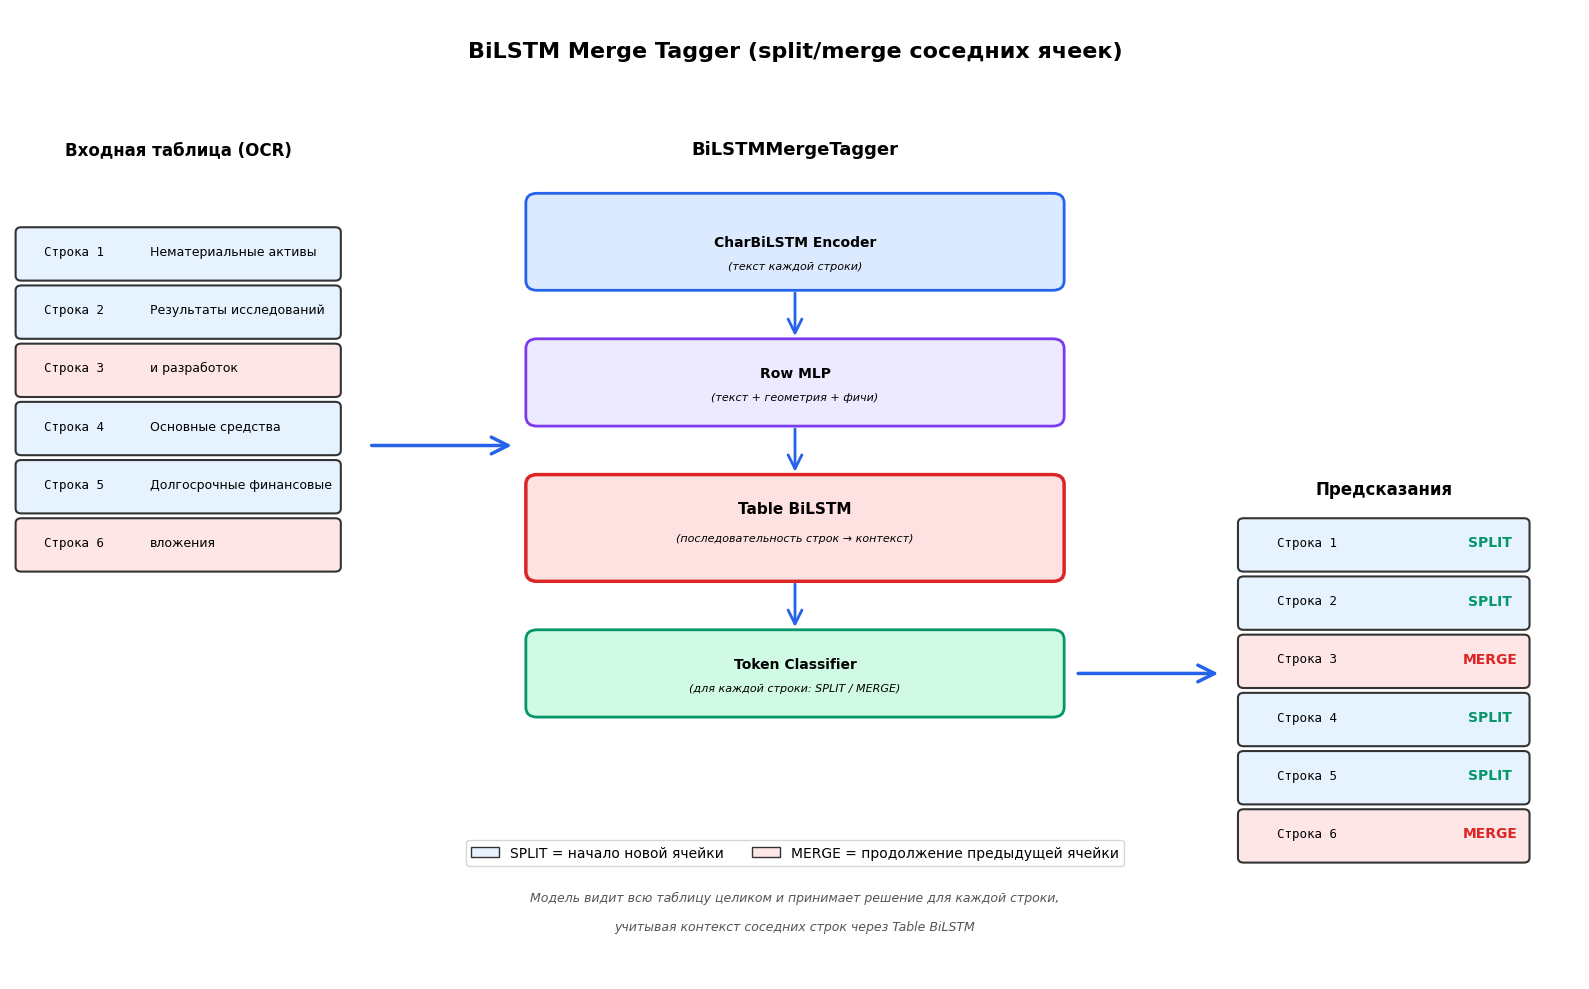

In [126]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# Заголовок
ax.text(7, 9.5, 'BiLSTM Merge Tagger (split/merge соседних ячеек)',
        ha='center', fontsize=16, fontweight='bold')

# Входная таблица (слева)
ax.text(1.5, 8.5, 'Входная таблица (OCR)', ha='center', fontsize=12, fontweight='bold')

table_rows = [
    ('Строка 1', '', 'Нематериальные активы', 'SPLIT'),
    ('Строка 2', '', 'Результаты исследований', 'SPLIT'),
    ('Строка 3', '', 'и разработок', 'MERGE'),
    ('Строка 4', '', 'Основные средства', 'SPLIT'),
    ('Строка 5', '', 'Долгосрочные финансовые', 'SPLIT'),
    ('Строка 6', '', 'вложения', 'MERGE'),
]

y_start = 7.5
for i, (idx, code, text, label) in enumerate(table_rows):
    y = y_start - i * 0.6
    color = '#ffe6e6' if label == 'MERGE' else '#e6f3ff'
    
    box = FancyBboxPatch((0.1, y-0.25), 2.8, 0.45,
                          boxstyle="round,pad=0.05", 
                          edgecolor='#333', facecolor=color, linewidth=1.5)
    ax.add_patch(box)
    
    ax.text(0.3, y, idx, ha='left', va='center', fontsize=9, fontfamily='monospace')
    ax.text(1.0, y, code if code else '', ha='center', va='center', 
            fontsize=9, fontfamily='monospace', color='#666')
    ax.text(1.25, y, text, ha='left', va='center', fontsize=9)

# Стрелка вправо
arrow1 = FancyArrowPatch((3.2, 5.5), (4.5, 5.5),
                         arrowstyle='->', mutation_scale=30, 
                         linewidth=2.5, color='#2563eb')
ax.add_patch(arrow1)

# Блок модели
ax.text(7, 8.5, 'BiLSTMMergeTagger', ha='center', fontsize=13, fontweight='bold')

# CharBiLSTM Encoder
char_box = FancyBboxPatch((4.7, 7.2), 4.6, 0.8,
                          boxstyle="round,pad=0.1",
                          edgecolor='#2563eb', facecolor='#dbeafe', linewidth=2)
ax.add_patch(char_box)
ax.text(7, 7.6, 'CharBiLSTM Encoder', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(7, 7.35, '(текст каждой строки)', ha='center', va='center', fontsize=8, style='italic')

# Стрелка вниз
arrow2 = FancyArrowPatch((7, 7.1), (7, 6.6),
                         arrowstyle='->', mutation_scale=25,
                         linewidth=2, color='#2563eb')
ax.add_patch(arrow2)

# Row MLP
mlp_box = FancyBboxPatch((4.7, 5.8), 4.6, 0.7,
                         boxstyle="round,pad=0.1",
                         edgecolor='#7c3aed', facecolor='#ede9fe', linewidth=2)
ax.add_patch(mlp_box)
ax.text(7, 6.25, 'Row MLP', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(7, 6.0, '(текст + геометрия + фичи)', ha='center', va='center', fontsize=8, style='italic')

# Стрелка вниз
arrow3 = FancyArrowPatch((7, 5.7), (7, 5.2),
                         arrowstyle='->', mutation_scale=25,
                         linewidth=2, color='#2563eb')
ax.add_patch(arrow3)

# Table BiLSTM
table_lstm_box = FancyBboxPatch((4.7, 4.2), 4.6, 0.9,
                                boxstyle="round,pad=0.1",
                                edgecolor='#dc2626', facecolor='#fee2e2', linewidth=2.5)
ax.add_patch(table_lstm_box)
ax.text(7, 4.85, 'Table BiLSTM', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(7, 4.55, '(последовательность строк → контекст)', ha='center', va='center',
        fontsize=8, style='italic')

# Стрелка вниз
arrow4 = FancyArrowPatch((7, 4.1), (7, 3.6),
                         arrowstyle='->', mutation_scale=25,
                         linewidth=2, color='#2563eb')
ax.add_patch(arrow4)

# Token Classifier
classifier_box = FancyBboxPatch((4.7, 2.8), 4.6, 0.7,
                                boxstyle="round,pad=0.1",
                                edgecolor='#059669', facecolor='#d1fae5', linewidth=2)
ax.add_patch(classifier_box)
ax.text(7, 3.25, 'Token Classifier', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(7, 3.0, '(для каждой строки: SPLIT / MERGE)', ha='center', va='center',
        fontsize=8, style='italic')

# Стрелка вправо
arrow5 = FancyArrowPatch((9.5, 3.15), (10.8, 3.15),
                         arrowstyle='->', mutation_scale=30,
                         linewidth=2.5, color='#2563eb')
ax.add_patch(arrow5)

# Выходные предсказания
ax.text(12.25, 5, 'Предсказания', ha='center', fontsize=12, fontweight='bold')

output_rows = [
    ('Строка 1', 'SPLIT', '#e6f3ff'),
    ('Строка 2', 'SPLIT', '#e6f3ff'),
    ('Строка 3', 'MERGE', '#ffe6e6'),
    ('Строка 4', 'SPLIT', '#e6f3ff'),
    ('Строка 5', 'SPLIT', '#e6f3ff'),
    ('Строка 6', 'MERGE', '#ffe6e6'),
]

y_start_out = 4.5
for i, (idx, label, color) in enumerate(output_rows):
    y = y_start_out - i * 0.6
    
    out_box = FancyBboxPatch((11.0, y-0.25), 2.5, 0.45,
                             boxstyle="round,pad=0.05",
                             edgecolor='#333', facecolor=color, linewidth=1.5)
    ax.add_patch(out_box)
    
    ax.text(11.3, y, idx, ha='left', va='center', fontsize=9, fontfamily='monospace')
    ax.text(13.2, y, label, ha='center', va='center', fontsize=10, fontweight='bold',
            color='#059669' if label == 'SPLIT' else '#dc2626')

# Легенда внизу
legend_y = 1.5
split_legend = mpatches.Patch(facecolor='#e6f3ff', edgecolor='#333', label='SPLIT = начало новой ячейки')
merge_legend = mpatches.Patch(facecolor='#ffe6e6', edgecolor='#333', label='MERGE = продолжение предыдущей ячейки')
ax.legend(handles=[split_legend, merge_legend], loc='upper center',
          bbox_to_anchor=(0.5, 0.15), ncol=2, frameon=True, fontsize=10)

# Аннотация
ax.text(7, 0.8, 'Модель видит всю таблицу целиком и принимает решение для каждой строки,',
        ha='center', fontsize=9, style='italic', color='#555')
ax.text(7, 0.5, 'учитывая контекст соседних строк через Table BiLSTM',
        ha='center', fontsize=9, style='italic', color='#555')

plt.tight_layout()
plt.savefig('bilstm_merge_tagger_schema.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [136]:
import random, numpy as np, pandas as pd
from collections import defaultdict

random.seed(SEED)
np.random.seed(SEED)


def make_page_pair_dataset(dfbio: pd.DataFrame, max_pairs_per_page: int = 3) -> list[dict]:
    """
    Строит датасет пар соседних страниц из dfpageslongbio.

    Для каждой пары (page_i, page_i+1) — реальных соседних страниц в датасете —
    вычисляем 5 бинарных меток:
      - page1_top_trunc  : page1 начинается посреди таблицы (I-TABLE в первой строке)
      - page1_bot_trunc  : page1 заканчивается посреди таблицы (B/I-TABLE в последней строке)
      - page2_top_trunc  : page2 начинается посреди таблицы
      - page2_bot_trunc  : page2 заканчивается посреди таблицы
      - is_continuation  : таблица в конце page1 == таблица в начале page2

    Дополнительно генерируем синтетические пары: разрезаем одну страницу в
    случайной точке, создавая виртуальную page2 из нижней половины той же страницы.
    Это позволяет контролировать баланс меток.
    """
    rng = np.random.default_rng(SEED)
    samples = []

    # ── 1. Реальные пары соседних страниц ──
    all_pids  = dfbio['page_id'].unique().tolist()
    pid_index = {pid: i for i, pid in enumerate(all_pids)}

    grouped = {pid: g.sort_values('page_row_index').reset_index(drop=True)
               for pid, g in dfbio.groupby('page_id')}

    for i in range(len(all_pids) - 1):
        pid1, pid2 = all_pids[i], all_pids[i + 1]
        df1, df2 = grouped[pid1], grouped[pid2]

        lbl = _compute_pair_labels(df1, df2)
        samples.append({'page1': df1, 'page2': df2, **lbl})

    # ── 2. Синтетические пары: разрез одной страницы ──
    for pid in all_pids:
        df = grouped[pid]
        n = len(df)
        if n < 6:
            continue
        for _ in range(max_pairs_per_page):
            sp = rng.integers(3, n - 3)
            df1 = df.iloc[:sp].reset_index(drop=True)
            df2 = df.iloc[sp:].reset_index(drop=True)
            lbl = _compute_pair_labels(df1, df2)
            samples.append({'page1': df1, 'page2': df2, **lbl})

    print(f"Всего пар: {len(samples)}")
    for key in ['page1_top_trunc', 'page1_bot_trunc', 'page2_top_trunc', 'page2_bot_trunc', 'is_continuation']:
        pos = sum(s[key] for s in samples)
        print(f"  {key}: pos={pos}, neg={len(samples)-pos}")
    return samples


def _compute_pair_labels(df1: pd.DataFrame, df2: pd.DataFrame) -> dict:
    """Вычисляет 5 меток для пары страниц на основе BIO-тегов."""
    def first_tag(df): return df.iloc[0]['bio_tag'] if len(df) else 'O'
    def last_tag(df):  return df.iloc[-1]['bio_tag'] if len(df) else 'O'
    def last_tid(df):  return df.iloc[-1]['table_id'] if len(df) else -1
    def first_tid(df): return df.iloc[0]['table_id']  if len(df) else -1

    p1_bot_trunc = int(last_tag(df1) in ('B-TABLE', 'I-TABLE'))
    p2_top_trunc = int(first_tag(df2) == 'I-TABLE')

    # is_continuation: конец page1 и начало page2 — одна и та же таблица
    # В синтетических парах tableid совпадает; в реальных — разные pageid,
    # поэтому используем позиционную эвристику: оба края — часть таблицы
    is_cont = int(p1_bot_trunc and p2_top_trunc)

    return dict(
        page1_top_trunc = int(first_tag(df1) == 'I-TABLE'),
        page1_bot_trunc = p1_bot_trunc,
        page2_top_trunc = p2_top_trunc,
        page2_bot_trunc = int(last_tag(df2) in ('B-TABLE', 'I-TABLE')),
        is_continuation = is_cont,
    )


pair_samples = make_page_pair_dataset(df_pages_long_bio)

Всего пар: 31999
  page1_top_trunc: pos=0, neg=31999
  page1_bot_trunc: pos=12867, neg=19132
  page2_top_trunc: pos=11783, neg=20216
  page2_bot_trunc: pos=2784, neg=29215
  is_continuation: pos=11783, neg=20216


In [140]:
# ── PagePairDataset ────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader

LABEL_KEYS = ['page1_top_trunc', 'page1_bot_trunc',
              'page2_top_trunc', 'page2_bot_trunc', 'is_continuation']


def _encode_page_df(df: pd.DataFrame, maxtextlen=64, maxcodelen=16) -> dict:
    """Кодирует DataFrame одной страницы в тензоры — тот же формат, что PageSequenceDataset."""
    T = len(df)
    numeric  = np.zeros((T, len(PAGE_NUMERIC_FEATURES)), dtype=np.float32)
    textids  = np.zeros((T, maxtextlen),  dtype=np.int64)
    textlen  = np.zeros(T, dtype=np.int64)
    codeids  = np.zeros((T, maxcodelen),  dtype=np.int64)
    codelen  = np.zeros(T, dtype=np.int64)

    if T > 1:
        seqpos = df['page_row_index'].values.astype(np.float32) / float(T - 1)
    else:
        seqpos = np.zeros(T, dtype=np.float32)
    seqlenarr = np.full(T, T, dtype=np.float32)

    for j, feat in enumerate(PAGE_NUMERIC_FEATURES):
        if feat == 'seqpos':
            numeric[:, j] = seqpos
        elif feat == 'seqlen':
            numeric[:, j] = seqlenarr
        else:
            try:
                numeric[:, j] = df[feat].values.astype(np.float32)
            except KeyError:
                pass

    for t in range(T):
        txt  = str(df.loc[df.index[t], 'row_text'])
        code = str(df.loc[df.index[t], 'row_code']) if 'row_code' in df.columns else ''

        ids_t, len_t = encodeTextToCharIds(txt, maxtextlen, PAD_CHAR_ID)
        textids[t, :len_t] = ids_t[:len_t];  textlen[t] = len_t

        ids_c, len_c = encodeTextToCharIds(code, maxcodelen, PAD_CHAR_ID)
        codeids[t, :len_c] = ids_c[:len_c];  codelen[t] = len_c

    return dict(
        textids  = torch.from_numpy(textids),   # T, Ltext
        textlen  = torch.from_numpy(textlen),   # T
        codeids  = torch.from_numpy(codeids),   # T, Lcode
        codelen  = torch.from_numpy(codelen),   # T
        numeric  = torch.from_numpy(numeric),   # T, D
        seqlen   = torch.tensor(T, dtype=torch.long),
    )


def encodeTextToCharIds(text, maxlen, padidx=0):
    """Повторно объявляем для автономности ячейки (если нет в scope — взять из Cell выше)."""
    try:
        return encodetext(text, stoi, maxlen=maxlen)   # функция из предыдущих ячеек
    except NameError:
        ids  = [stoi.get(c, stoi.get('<UNK>', 1)) for c in text[:maxlen]]
        length = len(ids)
        ids += [padidx] * (maxlen - length)
        return ids, length


class PagePairDataset(Dataset):
    """
    Каждый элемент — пара страниц (page1, page2) с 5 бинарными метками.
    Возвращает словарь с закодированными тензорами обеих страниц.
    """
    def __init__(self, samples, maxtextlen=64, maxcodelen=16):
        self.samples     = samples
        self.maxtextlen  = maxtextlen
        self.maxcodelen  = maxcodelen

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s  = self.samples[idx]
        p1 = _encode_page_df(s['page1'], self.maxtextlen, self.maxcodelen)
        p2 = _encode_page_df(s['page2'], self.maxtextlen, self.maxcodelen)
        labels = torch.tensor([s[k] for k in LABEL_KEYS], dtype=torch.float32)  # 5,
        return {'page1': p1, 'page2': p2, 'labels': labels}


def collate_pair_batch(batch):
    """
    Паддит каждую страницу в батче до Tmax для соответствующей страницы.
    Возвращает dict с ключами page1_*, page2_*, labels.
    """
    PADCHARID_LOCAL = 0

    def pad_pages(page_list):
        seqlens = torch.stack([p['seqlen'] for p in page_list])
        Tmax    = int(seqlens.max().item())
        B       = len(page_list)
        Ltext   = page_list[0]['textids'].shape[-1]
        Lcode   = page_list[0]['codeids'].shape[-1]
        Dnum    = page_list[0]['numeric'].shape[-1]

        textids = torch.zeros(B, Tmax, Ltext, dtype=torch.long)
        textlen = torch.zeros(B, Tmax, dtype=torch.long)
        codeids = torch.zeros(B, Tmax, Lcode, dtype=torch.long)
        codelen = torch.zeros(B, Tmax, dtype=torch.long)
        numeric = torch.zeros(B, Tmax, Dnum, dtype=torch.float32)

        for i, p in enumerate(page_list):
            T = p['seqlen'].item()
            textids[i, :T] = p['textids']
            textlen[i, :T] = p['textlen']
            codeids[i, :T] = p['codeids']
            codelen[i, :T] = p['codelen']
            numeric[i, :T] = p['numeric']

        return dict(textids=textids, textlen=textlen,
                    codeids=codeids, codelen=codelen,
                    numeric=numeric,  seqlens=seqlens)

    p1_batch = pad_pages([item['page1'] for item in batch])
    p2_batch = pad_pages([item['page2'] for item in batch])
    labels   = torch.stack([item['labels'] for item in batch])   # B, 5

    return {'page1': p1_batch, 'page2': p2_batch, 'labels': labels}


# ── Train/val split ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

pair_idx = np.arange(len(pair_samples))
train_pair_idx, valid_pair_idx = train_test_split(
    pair_idx, test_size=0.2, random_state=SEED
)

train_pair_ds = PagePairDataset([pair_samples[i] for i in train_pair_idx])
valid_pair_ds = PagePairDataset([pair_samples[i] for i in valid_pair_idx])

train_pair_loader = DataLoader(train_pair_ds, batch_size=16, shuffle=True,  collate_fn=collate_pair_batch)
valid_pair_loader = DataLoader(valid_pair_ds, batch_size=16, shuffle=False, collate_fn=collate_pair_batch)

print(f"Train pairs: {len(train_pair_ds)},  Valid pairs: {len(valid_pair_ds)}")
batch_ex = next(iter(train_pair_loader))
print("page1 textids:", batch_ex['page1']['textids'].shape)
print("page2 textids:", batch_ex['page2']['textids'].shape)
print("labels:       ", batch_ex['labels'].shape)

Train pairs: 25599,  Valid pairs: 6400
page1 textids: torch.Size([16, 40, 64])
page2 textids: torch.Size([16, 44, 64])
labels:        torch.Size([16, 5])


In [204]:
import torch.nn as nn
import torch.nn.functional as F


class PagePairBoundaryModel(nn.Module):
    """
    Архитектура:

        RowEncoder  (общий с BiLSTMRowTagger, параметры можно загрузить)
            |
        page_lstm  (bidirectional LSTM, тот же гиперпараметр hidden)
            |
            ├── PageBoundaryHead (per-page):
            │     [h_fwd_last ; h_bwd_first] → Linear → 2 логита
            │     (top_truncated, bot_truncated)
            │
            └── ContinuationHead (cross-page):
                  [page1_summary ; page2_summary ; page1*page2] → Linear → 1 логит
                  (is_continuation)

    Обучаем все 5 меток одновременно с BCE-loss.
    """

    def __init__(self, vocabsize, num_numeric_features,
                 row_hidden=128, page_hidden=128,
                 padidx=0, dropout=0.2):
        super().__init__()

        # 1) Общий RowEncoder (инициализируем свежим; ниже — загрузка весов)
        self.row_encoder = RowEncoder(
            vocab_size=vocabsize,
            num_numeric_features=num_numeric_features,
            row_hidden_dim=row_hidden,
            pad_idx=padidx,
            dropout=dropout,
        )

        # 2) page-level BiLSTM (один, используется поочерёдно для page1 и page2)
        self.page_lstm = nn.LSTM(
            input_size=self.row_encoder.output_dim,
            hidden_size=page_hidden,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)

        # 3) PageBoundaryHead — 2 бинарных класса на страницу
        #    вход: [h_fwd_last(dim=page_hidden) ; h_bwd_first(dim=page_hidden)]
        self.boundary_head = nn.Sequential(
            nn.Linear(page_hidden * 2, page_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(page_hidden, 2),   # [top_trunc, bot_trunc]
        )

        # 4) ContinuationHead — 1 бинарный класс на пару
        #    вход: [summary1 ; summary2 ; summary1*summary2]  (3 * page_hidden*2)
        self.continuation_head = nn.Sequential(
            nn.Linear(page_hidden * 2 * 3, page_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(page_hidden, 1),
        )

    # ── helpers ────────────────────────────────────────────────────────────────
    '''
    def _encode_page(self, page_batch: dict):
        """
        Прогоняет одну страницу через RowEncoder + page_lstm.
        Возвращает:
          - lstm_out : (B, T, 2*page_hidden)  — все скрытые состояния
          - summary  : (B, 2*page_hidden)     — [h_fwd_last ; h_bwd_first]
        """
        textids  = page_batch['textids']   # B, T, Ltext
        textlen  = page_batch['textlen']
        codeids  = page_batch['codeids']
        codelen  = page_batch['codelen']
        numeric  = page_batch['numeric']
        seqlens  = page_batch['seqlens']

        B, T, _ = textids.shape

        row_seq = self.row_encoder(
            text_ids=textids, text_len=textlen,
            code_ids=codeids, code_len=codelen,
            numeric=numeric,
        )  # B, T, row_dim

        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq, lengths=seqlens.cpu(),
            batch_first=True, enforce_sorted=False
        )
        packed_out, (hn, _) = self.page_lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=T
        )  # B, T, 2*page_hidden

        # hn shape: (2, B, page_hidden)  — [fwd_last, bwd_last]
        # h_fwd_last  = hn[0]  → последний токен в прямом направлении
        # h_bwd_first = hn[1]  → первый токен в обратном направлении  ← это "начало" страницы
        h_fwd = hn[0]   # B, page_hidden
        h_bwd = hn[1]   # B, page_hidden
        summary = torch.cat([h_fwd, h_bwd], dim=-1)   # B, 2*page_hidden
        return lstm_out, summary
    '''
        
    def _encode_page(self, page_batch):
        textids = page_batch['textids']   # B,T,L
        textlen = page_batch['textlen']   # B,T
        codeids = page_batch['codeids']
        codelen = page_batch['codelen']
        numeric = page_batch['numeric']

        B, T, _ = textids.shape

        # вместо seqlens из батча:
        # число строк с ненулевой длиной на каждую страницу
        seqlens = (textlen > 0).sum(dim=1)  # B

        row_seq = self.row_encoder(
            text_ids=textids, text_len=textlen,
            code_ids=codeids, code_len=codelen,
            numeric=numeric,
        )  # B,T,row_dim

        # упаковываем по seqlens
        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq,
            lengths=seqlens.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hn, _) = self.page_lstm(packed)
        if self.page_lstm.bidirectional:
            page_vec = torch.cat([hn[-2], hn[-1]], dim=-1)
        else:
            page_vec = hn[-1]
        return page_vec

    # ── forward ────────────────────────────────────────────────────────────────
    def forward(self, batch: dict):
        """
        batch = {'page1': {...}, 'page2': {...}, 'labels': (B,5)}
        Возвращает dict с логитами boundary1, boundary2, continuation.
        """
        summary1 = self._encode_page(batch['page1'])   # B, 2H
        summary2 = self._encode_page(batch['page2'])   # B, 2H

        # PageBoundaryHead для каждой страницы
        boundary1 = self.boundary_head(self.dropout(summary1))   # B, 2
        boundary2 = self.boundary_head(self.dropout(summary2))   # B, 2

        # ContinuationHead
        cont_feat = torch.cat([summary1, summary2, summary1 * summary2], dim=-1)
        continuation = self.continuation_head(self.dropout(cont_feat))  # B, 1

        return dict(boundary1=boundary1, boundary2=boundary2,
                    continuation=continuation)

    def predict_proba(self, batch: dict):
        """Возвращает вероятности (0-1) всех 5 меток."""
        out = self.forward(batch)
        p1 = torch.sigmoid(out['boundary1'])    # B, 2  [top_trunc, bot_trunc]
        p2 = torch.sigmoid(out['boundary2'])    # B, 2
        pc = torch.sigmoid(out['continuation']) # B, 1
        # Порядок: page1_top, page1_bot, page2_top, page2_bot, is_continuation
        return torch.cat([p1, p2, pc], dim=-1)  # B, 5


# ── Инициализация ────────────────────────────────────────────────────────────
PADIDX = stoi['<PAD>']

model_pair = PagePairBoundaryModel(
    vocabsize          = len(stoi) + 1,
    num_numeric_features = len(PAGE_NUMERIC_FEATURES),
    row_hidden         = 128,
    page_hidden        = 128,
    padidx             = PADIDX,
    dropout            = 0.2,
).to(device)

# ── (Опционально) загрузка весов RowEncoder + page_lstm из BiLSTMRowTagger ──
#   Раскомментируйте, если хотите warm-start с предобученного backbone:
#
# state = model.state_dict()          # model — BiLSTMRowTagger из предыдущих ячеек
# pair_state = model_pair.state_dict()
# for k, v in state.items():
#     if k.startswith('row_encoder.') or k.startswith('page_lstm.'):
#         pair_state[k] = v
# model_pair.load_state_dict(pair_state, strict=False)
# print("Weights transferred: row_encoder + page_lstm")

total_params = sum(p.numel() for p in model_pair.parameters())
trainable    = sum(p.numel() for p in model_pair.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}  |  Trainable: {trainable:,}")


Total params: 524,963  |  Trainable: 524,963


In [205]:
with torch.no_grad():
    model_pair.row_encoder.load_state_dict(model.row_encoder.state_dict())
    model_pair.page_lstm.load_state_dict(model.page_lstm.state_dict())  # или нужное имя

# замораживаем backbone
for p in list(model_pair.row_encoder.parameters()) + list(model_pair.page_lstm.parameters()):
    p.requires_grad = False

In [210]:
batch = next(iter(train_two_page_loader))
print(batch.keys())         # должны быть 'page1', 'page2', 'labels', 'sample_ids', 'scenarios'
print(batch['page1'].keys())  # numeric, textids, textlen, codeids, codelen, biolabels, seqlens
print(batch['labels'].shape)  # [B, 5]

dict_keys(['sample_ids', 'scenarios', 'page1', 'page2', 'labels'])
dict_keys(['numeric', 'textids', 'textlen', 'codeids', 'codelen', 'biolabels', 'seqlens'])
torch.Size([16, 5])


In [227]:
from tqdm.auto import tqdm

IGNORE_IDX = -100
NUM_EPOCHS_PAIR = 4
BEST_PATH_PAIR  = OUTPUT_DIR / 'pair_boundary_best.pt'

# BCE с логитами — для каждой из 5 меток независимо
criterion_pair = nn.BCEWithLogitsLoss()

optimizer_pair = torch.optim.AdamW(list(model_pair.boundary_head.parameters()) + list(model_pair.continuation_head.parameters()), lr=1e-3, weight_decay=1e-4)

scheduler_pair = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_pair, mode='max', factor=0.5, patience=2)

def _logits_and_labels(batch_out: dict, labels_batch: torch.Tensor):
    """
    Собирает все логиты и метки в плоские тензоры для BCE.
    labels_batch: B, 5  (page1_top, page1_bot, page2_top, page2_bot, is_cont)
    Возвращает logits_flat: B, 5 и labels_flat: B, 5
    """
    logits = torch.cat([
        batch_out['boundary1'],          # B, 2
        batch_out['boundary2'],          # B, 2
        batch_out['continuation'],       # B, 1
    ], dim=-1)   # B, 5
    return logits, labels_batch


def train_one_epoch_pair(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total_count = 0.0, 0, 0

    for batch in tqdm(loader, desc='pair-train', leave=False):
        page1 = {k: v.to(device) for k, v in batch['page1'].items()}
        page2 = {k: v.to(device) for k, v in batch['page2'].items()}
        labels = batch['labels'].to(device)   # B, 5

        optimizer.zero_grad()
        out     = model({'page1': page1, 'page2': page2})
        logits, lbl = _logits_and_labels(out, labels)

        loss = criterion(logits, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        preds = (logits.detach().sigmoid() > 0.5).float()
        total_loss    += loss.item() * lbl.shape[0]
        total_correct += (preds == lbl).all(dim=-1).sum().item()  # exact match
        total_count   += lbl.shape[0]

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate_pair(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='pair-valid', leave=False):
        page1  = {k: v.to(device) for k, v in batch['page1'].items()}
        page2  = {k: v.to(device) for k, v in batch['page2'].items()}
        labels = batch['labels'].to(device)

        out    = model({'page1': page1, 'page2': page2})
        logits, lbl = _logits_and_labels(out, labels)

        loss  = criterion(logits, lbl)
        preds = (logits.sigmoid() > 0.5).float()

        total_loss    += loss.item() * lbl.shape[0]
        total_correct += (preds == lbl).all(dim=-1).sum().item()
        total_count   += lbl.shape[0]
        all_preds.append(preds.cpu()); all_labels.append(lbl.cpu())

    avg_loss = total_loss / total_count
    avg_acc  = total_correct / total_count
    all_preds  = torch.cat(all_preds)    # N, 5
    all_labels = torch.cat(all_labels)   # N, 5

    # Per-label F1
    per_label_f1 = {}
    for i, name in enumerate(PAIR_LABEL_KEYS):
        tp = ((all_preds[:, i] == 1) & (all_labels[:, i] == 1)).sum().float()
        fp = ((all_preds[:, i] == 1) & (all_labels[:, i] == 0)).sum().float()
        fn = ((all_preds[:, i] == 0) & (all_labels[:, i] == 1)).sum().float()
        f1 = (2 * tp / (2 * tp + fp + fn + 1e-9)).item()
        per_label_f1[name] = f1

    return avg_loss, avg_acc, per_label_f1


best_val_acc_pair = -1.0
history_pair = []

for epoch in range(1, NUM_EPOCHS_PAIR + 1):
    tr_loss, tr_acc = train_one_epoch_pair(
        model_pair, train_two_page_loader, optimizer_pair, criterion_pair, device
    )
    val_loss, val_acc, val_f1 = evaluate_pair(
        model_pair, valid_two_page_loader, criterion_pair, device
    )
    scheduler_pair.step(val_acc)

    history_pair.append(dict(epoch=epoch, tr_loss=tr_loss, tr_acc=tr_acc,
                             val_loss=val_loss, val_acc=val_acc))

    f1_str = '  '.join(f'{k}={v:.3f}' for k, v in val_f1.items())
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_PAIR}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")
    print(f"  per-label F1: {f1_str}")

    if val_acc > best_val_acc_pair:
        best_val_acc_pair = val_acc
        torch.save(model_pair.state_dict(), BEST_PATH_PAIR)
        print(f"  ✓ Saved best model (val_acc={val_acc:.4f})")

print(f"\nBest val exact-match acc = {best_val_acc_pair:.4f}")

pair-train:   0%|          | 0/300 [00:00<?, ?it/s]

KeyError: 'page1_rows'

In [ ]:
# ── Инференс: предсказание для пары страниц ───────────────────────────────────

# Загружаем лучшие веса
model_pair.load_state_dict(torch.load(BEST_PATH_PAIR, map_location=device))
model_pair.eval()


def predict_page_pair(df_page1: pd.DataFrame, df_page2: pd.DataFrame,
                      threshold: float = 0.5) -> dict:
    """
    Принимает два DataFrame-а (одна страница каждый, тот же формат что dfpageslongbio).
    Возвращает dict с предсказаниями:
      {
        'page1_top_truncated'   : bool,
        'page1_bottom_truncated': bool,
        'page2_top_truncated'   : bool,
        'page2_bottom_truncated': bool,
        'is_continuation'       : bool,
        'probabilities'         : dict[str, float],
      }
    """
    p1 = _encode_page_df(df_page1)
    p2 = _encode_page_df(df_page2)

    def unsqueeze_page(p):
        return {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v
                for k, v in p.items()}

    batch = {'page1': unsqueeze_page(p1), 'page2': unsqueeze_page(p2)}

    with torch.no_grad():
        probs = model_pair.predict_proba(batch).squeeze(0).cpu().numpy()  # 5,

    result = {name: bool(probs[i] > threshold) for i, name in enumerate(LABEL_KEYS)}
    result['probabilities'] = {name: float(probs[i]) for i, name in enumerate(LABEL_KEYS)}

    # Читаемые имена
    readable = {
        'page1_top_trunc'  : 'page1_top_truncated',
        'page1_bot_trunc'  : 'page1_bottom_truncated',
        'page2_top_trunc'  : 'page2_top_truncated',
        'page2_bot_trunc'  : 'page2_bottom_truncated',
        'is_continuation'  : 'is_continuation',
    }
    return {readable.get(k, k): v for k, v in result.items()}


# ── Демо на первой паре из валидационного сета ────────────────────────────────
demo_sample = pair_samples[valid_pair_idx[0]]
pred = predict_page_pair(demo_sample['page1'], demo_sample['page2'])

print("=== Предсказание для пары страниц ===")
for k, v in pred.items():
    if k != 'probabilities':
        gt_key = {
            'page1_top_truncated'   : 'page1_top_trunc',
            'page1_bottom_truncated': 'page1_bot_trunc',
            'page2_top_truncated'   : 'page2_top_trunc',
            'page2_bottom_truncated': 'page2_bot_trunc',
            'is_continuation'       : 'is_continuation',
        }[k]
        gt = bool(demo_sample[gt_key])
        mark = '✓' if v == gt else '✗'
        print(f"  {mark} {k:30s}: pred={v}  gt={gt}  p={pred['probabilities'].get(gt_key, '?'):.3f}")

In [ ]:
# ── Итоговый отчёт по метрикам ────────────────────────────────────────────────
from sklearn.metrics import classification_report

model_pair.load_state_dict(torch.load(BEST_PATH_PAIR, map_location=device))
model_pair.eval()

all_preds_np, all_labels_np = [], []

with torch.no_grad():
    for batch in tqdm(valid_pair_loader, desc='Final eval', leave=False):
        page1  = {k: v.to(device) for k, v in batch['page1'].items()}
        page2  = {k: v.to(device) for k, v in batch['page2'].items()}
        labels = batch['labels']

        out    = model_pair({'page1': page1, 'page2': page2})
        logits = torch.cat([out['boundary1'], out['boundary2'], out['continuation']], dim=-1)
        preds  = (logits.sigmoid() > 0.5).float().cpu()

        all_preds_np.append(preds.numpy())
        all_labels_np.append(labels.numpy())

all_preds_np  = np.vstack(all_preds_np)    # N, 5
all_labels_np = np.vstack(all_labels_np)   # N, 5

readable_names = [
    'page1_top_trunc', 'page1_bot_trunc',
    'page2_top_trunc', 'page2_bot_trunc',
    'is_continuation',
]

print("=== Per-label Classification Report ===\n")
for i, name in enumerate(readable_names):
    print(f"── {name}")
    print(classification_report(
        all_labels_np[:, i], all_preds_np[:, i],
        target_names=['neg', 'pos'], digits=4
    ))

exact_match = (all_preds_np == all_labels_np).all(axis=1).mean()
print(f"Exact-match accuracy (все 5 меток верны): {exact_match:.4f}")

In [157]:
# 1) Сколько параметров у backbone и сколько из них обучаемых сейчас
enc_params_total = sum(p.numel() for p in model_pair.row_encoder.parameters())
enc_params_train = sum(p.numel() for p in model_pair.row_encoder.parameters()
                       if p.requires_grad)
page_params_total = sum(p.numel() for p in model_pair.page_lstm.parameters())
page_params_train = sum(p.numel() for p in model_pair.page_lstm.parameters()
                        if p.requires_grad)

head_params_train = sum(p.numel() for p in model_pair.boundary_head.parameters()
                        if p.requires_grad) \
                  + sum(p.numel() for p in model_pair.continuation_head.parameters()
                        if p.requires_grad)

print(f"RowEncoder: total={enc_params_total}, trainable={enc_params_train}")
print(f"Page LSTM: total={page_params_total}, trainable={page_params_train}")
print(f"Heads trainable params = {head_params_train}")

RowEncoder: total=129056, trainable=0
Page LSTM: total=264192, trainable=0
Heads trainable params = 131715


In [166]:
def decode_textids_row(textids_row, textlen_i, itos):
    # textids_row: (L,), textlen_i: scalar
    chars = []
    for idx in textids_row[:int(textlen_i)]:
        idx = int(idx)
        chars.append(itos[idx])
    return ''.join(chars)

def show_pair_sample(dataset, idx, itos, max_rows=10):
    sample = dataset[idx]
    p1 = sample['page1']
    p2 = sample['page2']
    labels = sample['labels'].numpy()

    print(f"=== SAMPLE #{idx} ===")
    print(f"labels: page1_top_trunc={labels[0]}, page1_bot_trunc={labels[1]}, "
          f"page2_top_trunc={labels[2]}, page2_bot_trunc={labels[3]}, "
          f"is_continuation={labels[4]}")
    print()

    def _show_page(p, title):
        textids = p['textids']   # shape (T,L) или (1,T,L)
        textlen = p['textlen']   # shape (T,) или (1,T)

        # приведём к (T,L) и (T,)
        if textids.ndim == 3:
            textids = textids[0]
        if textlen.ndim == 2:
            textlen = textlen[0]

        # число реальных строк возьмём по ненулевой длине
        mask = (textlen > 0)
        seqlen = int(mask.sum().item())

        print(f"{title}: seqlen={seqlen}")
        for i in range(min(seqlen, max_rows)):
            row_chars = decode_textids_row(textids[i], textlen[i], itos)
            print(f"  [{i:02d}] {row_chars}")
        print()

    _show_page(p1, "PAGE 1")
    _show_page(p2, "PAGE 2")

In [168]:
for i in range(3):
    show_pair_sample(train_pair_ds, i, itos, max_rows=30)

=== SAMPLE #0 ===
labels: page1_top_trunc=0.0, page1_bot_trunc=1.0, page2_top_trunc=1.0, page2_bot_trunc=0.0, is_continuation=1.0

PAGE 1: seqlen=17
  [00] Вид экономической деятельности
  [01] по ОКОПФ / ОКФС
  [02] Дата
  [03] по ОКВЭД
  [04] Наиенование экономиескоо суб<UNK>ект
  [05] Главный бухгалтер
  [06] Приложение <UNK> 10 к ФСБУ 4/2023
  [07] Пояснения
  [08] Единица измерения: тыс<UNK> руб<UNK>
  [09] Дата
  [10] по ОКОПФ / ОКФС
  [11] пoOКОПФ / ОКФС
  [12] Приложение <UNK> 10 к ФСБУ 4/2023
  [13] Примечание
  [14] КПП
  [15] в тo чсе:(п ам 331, 3232…
  [16] РеоргИзЦЯРиичеКо ЛИ ц А

PAGE 2: seqlen=24
  [00] ИНЫe И зЕен иЯ –вс
  [01] в тM числЕ: пbдам 3241, 32…
  [02] ли чин ка пит лa aTy ок oн чa п еи о аПpыущo о да аа гич нгоo тч
  [03] BИчин К и На 31декaряПp Еддще го ОДа
  [04] коРрЕктрОвК А В с в ЯЗ и с ИЗмЕ нен ие м у ЧЕтНо йП олиТиК и
  [05] рк тро к cвЗСИсрв лнеm об K
  [06] В елкаТаа на31 де кРыдщ ода Оcлe kop p ЕтрОки
  [07] са п рблy быoк )
  [08] Адрес
  [09] Прил

In [169]:
import torch
import torch.nn.functional as F

def decode_textids_row(textids_row, textlen_i, itos):
    chars = []
    for idx in textids_row[:int(textlen_i)]:
        idx = int(idx)
        chars.append(itos[idx])
    return ''.join(chars)


def show_pair_sample(dataset, idx, itos, model_pair, device, max_rows=10):
    sample = dataset[idx]
    p1 = sample['page1']
    p2 = sample['page2']
    labels = sample['labels'].numpy().astype(int)

    # ---- подготовка входа для модели ----
    # добавляем batch dimension
    batch = {
        'page1': {
            'textids': p1['textids'].unsqueeze(0),
            'textlen': p1['textlen'].unsqueeze(0),
            'codeids': p1['codeids'].unsqueeze(0),
            'codelen': p1['codelen'].unsqueeze(0),
            'numeric': p1['numeric'].unsqueeze(0),
        },
        'page2': {
            'textids': p2['textids'].unsqueeze(0),
            'textlen': p2['textlen'].unsqueeze(0),
            'codeids': p2['codeids'].unsqueeze(0),
            'codelen': p2['codelen'].unsqueeze(0),
            'numeric': p2['numeric'].unsqueeze(0),
        },
    }

    batch = {k: {kk: vv.to(device) for kk, vv in v.items()} for k, v in batch.items()}

    model_pair.eval()
    with torch.no_grad():
        logits = model_pair(batch)          # shape: (B, 5)
        probs = torch.sigmoid(logits)[0]    # (5,)
        preds = (probs > 0.5).long().cpu().numpy().astype(int)

    names = ["p1_top_trunc", "p1_bot_trunc", "p2_top_trunc", "p2_bot_trunc", "is_continuation"]
    print(f"=== SAMPLE #{idx} ===")
    print("GT:")
    for n, v in zip(names, labels):
        print(f"  {n:16s} = {v}")
    print("Pred:")
    for n, v, pr in zip(names, preds, probs.cpu().numpy()):
        print(f"  {n:16s} = {v} (p={pr:.3f})")
    print()

    def _show_page(p, title):
        textids = p['textids']
        textlen = p['textlen']
        if textids.ndim == 3:
            textids = textids[0]
        if textlen.ndim == 2:
            textlen = textlen[0]
        mask = (textlen > 0)
        seqlen = int(mask.sum().item())

        print(f"{title}: seqlen={seqlen}")
        for i in range(min(seqlen, max_rows)):
            row_chars = decode_textids_row(textids[i], textlen[i], itos)
            print(f"  [{i:02d}] {row_chars}")
        print()

    _show_page(p1, "PAGE 1")
    _show_page(p2, "PAGE 2")

In [185]:
for i in range(3):
    show_pair_sample(train_pair_ds, i, itos, model_pair, device, max_rows=8)

TypeError: sigmoid(): argument 'input' (position 1) must be Tensor, not dict

In [199]:
import random
from copy import deepcopy
import numpy as np

PAIR_LABEL_KEYS = [
    "page1_top_trunc",
    "page1_bot_trunc",
    "page2_top_trunc",
    "page2_bot_trunc",
    "is_continuation",
]

BIO_TAGS = ["O", "B-TABLE", "I-TABLE"]
BIO_TAG2ID = {t: i for i, t in enumerate(BIO_TAGS)}


def clone_record(rec):
    return dict(rec)


def sample_table_rows_from_templates(classname, templates):
    """
    Генерирует одну таблицу тем же генератором, что и раньше:
    generate_one_sample(templaterows, classname)
    """
    templaterows = templates[classname]
    rows = generate_one_sample(templaterows, classname)

    out = []
    for i, row in enumerate(rows):
        rec = clone_record(row)
        rec["tableclassname"] = classname
        rec["src_seqpos"] = i
        out.append(rec)
    return out


def sample_noise_rows(n_rows):
    out = []
    for i in range(n_rows):
        rec = make_noise_row(i, max(n_rows, 1))
        rec = dict(rec)
        rec["tableclassname"] = None
        out.append(rec)
    return out


def finalize_page_rows(page_blocks, page_id):
    """
    page_blocks:
      {"kind": "noise", "rows": [...]}
      {"kind": "table", "rows": [...], "table_id": int, "first_tag": "B-TABLE"/"I-TABLE"}
    """
    all_rows = []
    pagerowindex = 0

    for block in page_blocks:
        kind = block["kind"]

        if kind == "noise":
            for row in block["rows"]:
                rec = clone_record(row)
                rec["page_row_index"] = pagerowindex
                rec["seq_pos"] = pagerowindex
                rec["is_table_row"] = 0
                rec["table_id"] = -1
                rec["table_local_row"] = -1
                rec["bio_tag"] = "O"
                all_rows.append(rec)
                pagerowindex += 1

        elif kind == "table":
            first_tag = block.get("first_tag", "B-TABLE")
            for local_idx, row in enumerate(block["rows"]):
                rec = clone_record(row)
                rec["page_row_index"] = pagerowindex
                rec["seq_pos"] = pagerowindex
                rec["is_table_row"] = 1
                rec["table_id"] = int(block["table_id"])
                rec["table_local_row"] = local_idx
                rec["bio_tag"] = first_tag if local_idx == 0 else "I-TABLE"
                all_rows.append(rec)
                pagerowindex += 1
        else:
            raise ValueError(f"Unknown block kind: {kind}")

    total_rows = len(all_rows)

    for rec in all_rows:
        geom = synthetic_bbox_features(
            rec.get("row_text", ""),
            rec.get("row_code", ""),
            rec["page_row_index"],
            total_rows,
        )
        stats = row_text_stats(rec.get("row_text", ""))

        rec.update(geom)
        rec.update(stats)

        rec["seq_len"] = total_rows
        rec["page_id"] = page_id
        rec["bio_id"] = BIO_TAG2ID[rec["bio_tag"]]

    return all_rows


def first_table_row_index(rows):
    for i, r in enumerate(rows):
        if r["is_table_row"] == 1:
            return i
    return None


def last_table_row_index(rows):
    for i in range(len(rows) - 1, -1, -1):
        if rows[i]["is_table_row"] == 1:
            return i
    return None


def compute_pair_labels(page1_rows, page2_rows):
    def first_tag(rows):
        idx = first_table_row_index(rows)
        if idx is None:
            return "O"
        return rows[idx]["bio_tag"]

    def last_tag(rows):
        idx = last_table_row_index(rows)
        if idx is None:
            return "O"
        return rows[idx]["bio_tag"]

    page1_top_trunc = int(first_tag(page1_rows) == "I-TABLE")
    page1_bot_trunc = int(last_tag(page1_rows) in ("B-TABLE", "I-TABLE"))
    page2_top_trunc = int(first_tag(page2_rows) == "I-TABLE")
    page2_bot_trunc = int(last_tag(page2_rows) in ("B-TABLE", "I-TABLE"))
    is_continuation = int(page1_bot_trunc and page2_top_trunc)

    return {
        "page1_top_trunc": page1_top_trunc,
        "page1_bot_trunc": page1_bot_trunc,
        "page2_top_trunc": page2_top_trunc,
        "page2_bot_trunc": page2_bot_trunc,
        "is_continuation": is_continuation,
    }


def split_long_table_into_fragments(long_table_rows, min_fragment_len=2):
    n = len(long_table_rows)

    if n < 2 * min_fragment_len + 1:
        split_points = [max(1, n // 2)]
    else:
        if random.random() < 0.35 and n >= 3 * min_fragment_len:
            pts = sorted(random.sample(range(min_fragment_len, n - min_fragment_len + 1), 2))
            if pts[1] - pts[0] < min_fragment_len:
                split_points = [pts[0]]
            else:
                split_points = pts
        else:
            split_points = [random.randint(min_fragment_len, n - min_fragment_len)]

    fragments = []
    prev = 0
    for p in split_points:
        fragments.append(deepcopy(long_table_rows[prev:p]))
        prev = p
    fragments.append(deepcopy(long_table_rows[prev:]))

    return fragments


def build_one_table_two_pages_sample(sample_idx, templates, page_len_range=(25, 45)):
    classname = random.choice(list(templates.keys()))

    n_chunks = random.randint(2, 4)
    long_table_rows = []
    for _ in range(n_chunks):
        long_table_rows.extend(sample_table_rows_from_templates(classname, templates))

    if len(long_table_rows) < 8:
        long_table_rows = long_table_rows * 2

    fragments = split_long_table_into_fragments(long_table_rows, min_fragment_len=2)

    if len(fragments) == 2:
        visible_fragment_1 = fragments[0]
        visible_fragment_2 = fragments[1]
        has_hidden_left = 0
        has_hidden_right = 0
    else:
        start_idx = random.randint(0, len(fragments) - 2)
        visible_fragment_1 = fragments[start_idx]
        visible_fragment_2 = fragments[start_idx + 1]
        has_hidden_left = int(start_idx > 0)
        has_hidden_right = int(start_idx + 1 < len(fragments) - 1)

    page1_len_target = random.randint(*page_len_range)
    page2_len_target = random.randint(*page_len_range)

    page1_noise_budget = max(0, page1_len_target - len(visible_fragment_1))
    page2_noise_budget = max(0, page2_len_target - len(visible_fragment_2))

    page1_prefix_noise = random.randint(0, page1_noise_budget)
    page1_suffix_noise = page1_noise_budget - page1_prefix_noise

    page2_prefix_noise = random.randint(0, page2_noise_budget)
    page2_suffix_noise = page2_noise_budget - page2_prefix_noise

    page1_blocks = [
        {"kind": "noise", "rows": sample_noise_rows(page1_prefix_noise)},
        {
            "kind": "table",
            "rows": visible_fragment_1,
            "table_id": 0,
            "first_tag": "I-TABLE" if has_hidden_left else "B-TABLE",
        },
        {"kind": "noise", "rows": sample_noise_rows(page1_suffix_noise)},
    ]

    page2_blocks = [
        {"kind": "noise", "rows": sample_noise_rows(page2_prefix_noise)},
        {
            "kind": "table",
            "rows": visible_fragment_2,
            "table_id": 0,
            "first_tag": "I-TABLE",
        },
        {"kind": "noise", "rows": sample_noise_rows(page2_suffix_noise)},
    ]

    page1_rows = finalize_page_rows(page1_blocks, f"pair{sample_idx:06d}_p1")
    page2_rows = finalize_page_rows(page2_blocks, f"pair{sample_idx:06d}_p2")

    labels = compute_pair_labels(page1_rows, page2_rows)
    labels["page1_top_trunc"] = int(has_hidden_left)
    labels["page2_top_trunc"] = 1
    labels["page2_bot_trunc"] = int(has_hidden_right)
    labels["is_continuation"] = 1

    return {
        "sample_id": f"pair{sample_idx:06d}",
        "scenario": "one_table",
        "page1_rows": page1_rows,
        "page2_rows": page2_rows,
        "labels": labels,
    }


def build_two_tables_two_pages_sample(sample_idx, templates, page_len_range=(25, 45)):
    classname1 = random.choice(list(templates.keys()))
    classname2 = random.choice(list(templates.keys()))

    table1_rows = sample_table_rows_from_templates(classname1, templates)
    table2_rows = sample_table_rows_from_templates(classname2, templates)

    table1_top_trunc = 0
    table2_bot_trunc = 0

    if len(table1_rows) >= 4 and random.random() < 0.6:
        cut = random.randint(1, max(1, len(table1_rows) // 3))
        table1_rows = table1_rows[cut:]
        table1_top_trunc = 1

    if len(table2_rows) >= 4 and random.random() < 0.6:
        cut = random.randint(1, max(1, len(table2_rows) // 3))
        table2_rows = table2_rows[:-cut]
        table2_bot_trunc = 1

    boundary_on_page1 = (random.random() < 0.5)

    page1_len_target = random.randint(*page_len_range)
    page2_len_target = random.randint(*page_len_range)

    if boundary_on_page1:
        table2_part_on_page1_len = min(len(table2_rows), random.randint(1, max(1, len(table2_rows) // 2)))
        table2_rows_page1 = deepcopy(table2_rows[:table2_part_on_page1_len])
        table2_rows_page2 = deepcopy(table2_rows[table2_part_on_page1_len:])

        used1 = len(table1_rows) + len(table2_rows_page1)
        noise1 = max(0, page1_len_target - used1)
        n1a = random.randint(0, noise1)
        n1b = random.randint(0, noise1 - n1a)
        n1c = noise1 - n1a - n1b

        page1_blocks = [
            {"kind": "noise", "rows": sample_noise_rows(n1a)},
            {
                "kind": "table",
                "rows": deepcopy(table1_rows),
                "table_id": 0,
                "first_tag": "I-TABLE" if table1_top_trunc else "B-TABLE",
            },
            {"kind": "noise", "rows": sample_noise_rows(n1b)},
            {
                "kind": "table",
                "rows": table2_rows_page1,
                "table_id": 1,
                "first_tag": "B-TABLE",
            },
            {"kind": "noise", "rows": sample_noise_rows(n1c)},
        ]

        used2 = len(table2_rows_page2)
        noise2 = max(0, page2_len_target - used2)
        n2a = random.randint(0, noise2)
        n2b = noise2 - n2a

        page2_blocks = [
            {"kind": "noise", "rows": sample_noise_rows(n2a)},
        ]
        if len(table2_rows_page2) > 0:
            page2_blocks.append({
                "kind": "table",
                "rows": table2_rows_page2,
                "table_id": 1,
                "first_tag": "I-TABLE",
            })
        page2_blocks.append({"kind": "noise", "rows": sample_noise_rows(n2b)})

    else:
        table1_part_on_page1_len = min(len(table1_rows), random.randint(1, max(1, len(table1_rows) // 2)))
        table1_rows_page1 = deepcopy(table1_rows[:table1_part_on_page1_len])
        table1_rows_page2 = deepcopy(table1_rows[table1_part_on_page1_len:])

        used1 = len(table1_rows_page1)
        noise1 = max(0, page1_len_target - used1)
        n1a = random.randint(0, noise1)
        n1b = noise1 - n1a

        page1_blocks = [
            {"kind": "noise", "rows": sample_noise_rows(n1a)},
            {
                "kind": "table",
                "rows": table1_rows_page1,
                "table_id": 0,
                "first_tag": "I-TABLE" if table1_top_trunc else "B-TABLE",
            },
            {"kind": "noise", "rows": sample_noise_rows(n1b)},
        ]

        used2 = len(table1_rows_page2) + len(table2_rows)
        noise2 = max(0, page2_len_target - used2)
        n2a = random.randint(0, noise2)
        n2b = random.randint(0, noise2 - n2a)
        n2c = noise2 - n2a - n2b

        page2_blocks = [
            {"kind": "noise", "rows": sample_noise_rows(n2a)},
        ]
        if len(table1_rows_page2) > 0:
            page2_blocks.append({
                "kind": "table",
                "rows": table1_rows_page2,
                "table_id": 0,
                "first_tag": "I-TABLE",
            })
        page2_blocks.extend([
            {"kind": "noise", "rows": sample_noise_rows(n2b)},
            {
                "kind": "table",
                "rows": deepcopy(table2_rows),
                "table_id": 1,
                "first_tag": "B-TABLE",
            },
            {"kind": "noise", "rows": sample_noise_rows(n2c)},
        ])

    page1_rows = finalize_page_rows(page1_blocks, f"pair{sample_idx:06d}_p1")
    page2_rows = finalize_page_rows(page2_blocks, f"pair{sample_idx:06d}_p2")

    labels = compute_pair_labels(page1_rows, page2_rows)

    labels["page1_top_trunc"] = int(table1_top_trunc)

    last_tbl_idx_p1 = last_table_row_index(page1_rows)
    first_tbl_idx_p2 = first_table_row_index(page2_rows)

    if last_tbl_idx_p1 is not None and first_tbl_idx_p2 is not None:
        labels["is_continuation"] = int(
            page1_rows[last_tbl_idx_p1]["table_id"] == page2_rows[first_tbl_idx_p2]["table_id"]
        )
    else:
        labels["is_continuation"] = 0

    if not any(r["is_table_row"] == 1 and r["table_id"] == 1 for r in page2_rows):
        labels["page2_bot_trunc"] = 0
    else:
        labels["page2_bot_trunc"] = int(table2_bot_trunc)

    return {
        "sample_id": f"pair{sample_idx:06d}",
        "scenario": "two_tables",
        "page1_rows": page1_rows,
        "page2_rows": page2_rows,
        "labels": labels,
    }


def build_two_page_samples_from_templates(
    templates,
    n_samples=4000,
    p_one_table=0.5,
    page_len_range=(25, 45),
    seed=42,
):
    random.seed(seed)
    np.random.seed(seed)

    samples = []
    for sample_idx in range(n_samples):
        if random.random() < p_one_table:
            sample = build_one_table_two_pages_sample(
                sample_idx, templates, page_len_range=page_len_range
            )
        else:
            sample = build_two_tables_two_pages_sample(
                sample_idx, templates, page_len_range=page_len_range
            )
        samples.append(sample)
    return samples


# --- пример генерации ---
two_page_samples = build_two_page_samples_from_templates(
    templates=templates,
    n_samples=3000,
    p_one_table=0.5,
    page_len_range=(25, 45),
    seed=SEED,
)

print("n_samples =", len(two_page_samples))
print("example labels =", two_page_samples[0]["labels"])
print("page1 rows =", len(two_page_samples[0]["page1_rows"]))
print("page2 rows =", len(two_page_samples[0]["page2_rows"]))

n_samples = 3000
example labels = {'page1_top_trunc': 0, 'page1_bot_trunc': 1, 'page2_top_trunc': 1, 'page2_bot_trunc': 1, 'is_continuation': 1}
page1 rows = 27
page2 rows = 38


In [219]:
# ── realistic pair-page generator: full pages only, snake_case only ──────────
import random
from copy import deepcopy

import numpy as np
import pandas as pd


PAIR_PAGE_LEN_MIN = 25
PAIR_PAGE_LEN_MAX = 45
PAIR_MIN_ROWS_PER_PAGE = 10

PAIR_P_ONE_TABLE = 0.55
PAIR_P_TWO_TABLES = 0.45

assert abs(PAIR_P_ONE_TABLE + PAIR_P_TWO_TABLES - 1.0) < 1e-9


def sample_pair_page_len():
    page_len_1 = random.randint(PAIR_PAGE_LEN_MIN, PAIR_PAGE_LEN_MAX)
    page_len_2 = random.randint(PAIR_PAGE_LEN_MIN, PAIR_PAGE_LEN_MAX)
    return page_len_1, page_len_2


def copy_rows(rows):
    return [deepcopy(row) for row in rows]


def trim_table_rows(rows, min_keep=6):
    rows = copy_rows(rows)
    n_rows = len(rows)

    if n_rows <= min_keep:
        return rows

    keep_n = random.randint(min_keep, n_rows)
    start_idx = random.randint(0, n_rows - keep_n)
    return rows[start_idx:start_idx + keep_n]


def make_noise_row_at(page_row_index, total_rows):
    if 'makenoiserow' in globals():
        return makenoiserow(page_row_index, total_rows)

    base_text = random.choice(PAGENOISELINES) if 'PAGENOISELINES' in globals() else ''
    row_text = augmenttextocr(
        base_text,
        pconfuse=np.random.uniform(0.0, 0.04),
        pdelete=np.random.uniform(0.0, 0.02),
        pspace=np.random.uniform(0.0, 0.02),
        pcase=np.random.uniform(0.0, 0.01),
    ) if 'augmenttextocr' in globals() else base_text

    geom = syntheticbboxfeatures(row_text, '', page_row_index, total_rows) if 'syntheticbboxfeatures' in globals() else {}
    stats = rowtextstats(row_text) if 'rowtextstats' in globals() else {}

    return {
        'rowtext': row_text,
        'rowcode': '',
        'codelen': 0,
        'numdigitscode': 0,
        **geom,
        **stats,
        'pagerowindex': int(page_row_index),
        'istablerow': 0,
        'tableid': -1,
        'tablelocalrow': -1,
        'tableclassname': None,
    }


def make_noise_block(n_rows, start_page_row_index, total_rows):
    rows = []
    for offset in range(n_rows):
        rows.append(make_noise_row_at(start_page_row_index + offset, total_rows))
    return rows


def table_rows_to_page_rows(table_rows, table_id, start_page_row_index, total_rows):
    page_rows = []

    for local_idx, row in enumerate(table_rows):
        row_text = row.get('rowtext', '')
        row_code = row.get('rowcode', '')

        geom = syntheticbboxfeatures(
            row_text,
            row_code,
            rowpos=start_page_row_index + local_idx,
            totalrows=total_rows,
        ) if 'syntheticbboxfeatures' in globals() else {}

        stats = rowtextstats(row_text) if 'rowtextstats' in globals() else {}

        rec = {
            'rowtext': row_text,
            'rowcode': row_code,
            'codelen': len(row_code),
            'numdigitscode': len([ch for ch in row_code if ch.isdigit()]),
            **geom,
            **stats,
            'pagerowindex': int(start_page_row_index + local_idx),
            'istablerow': 1,
            'tableid': int(table_id),
            'tablelocalrow': int(local_idx),
            'tableclassname': row.get('classname', None),
        }
        page_rows.append(rec)

    return page_rows


def finalize_page_rows(rows, page_id, page_len):
    assert len(rows) == page_len, f'len(rows)={len(rows)} != page_len={page_len}'

    has_table = int(any(row.get('istablerow', 0) == 1 for row in rows))
    out_rows = []

    for page_row_index, row in enumerate(rows):
        rec = dict(row)
        rec['pagerowindex'] = int(page_row_index)

        row_text = rec.get('rowtext', '')
        row_code = rec.get('rowcode', '')

        if 'syntheticbboxfeatures' in globals():
            rec.update(
                syntheticbboxfeatures(
                    row_text,
                    row_code,
                    rowpos=page_row_index,
                    totalrows=page_len,
                )
            )

        if 'rowtextstats' in globals():
            rec.update(rowtextstats(row_text))

        rec['pageid'] = page_id
        rec['pagehastable'] = has_table
        out_rows.append(rec)

    return out_rows


def ensure_bio_on_page(df_page):
    df_page = df_page.copy().sort_values('pagerowindex').reset_index(drop=True)

    if 'biotag' in df_page.columns and 'bioid' in df_page.columns:
        return df_page

    df_page['biotag'] = 'O'

    table_mask = df_page['istablerow'] == 1
    if table_mask.any():
        for table_id, group in df_page.loc[table_mask].groupby('tableid'):
            if table_id == -1:
                continue
            idxs = group.sort_values('pagerowindex').index.tolist()
            if len(idxs) >= 1:
                df_page.loc[idxs[0], 'biotag'] = 'B-TABLE'
            if len(idxs) >= 2:
                df_page.loc[idxs[1:], 'biotag'] = 'I-TABLE'

    bio_tag_to_id = {'O': 0, 'B-TABLE': 1, 'I-TABLE': 2}
    df_page['bioid'] = df_page['biotag'].map(bio_tag_to_id).astype(np.int64)
    return df_page


def first_tag(df_page):
    if len(df_page) == 0:
        return 'O'
    return str(df_page.iloc[0].get('biotag', 'O'))


def last_tag(df_page):
    if len(df_page) == 0:
        return 'O'
    return str(df_page.iloc[-1].get('biotag', 'O'))


def compute_pair_labels(df_page_1, df_page_2):
    page_1_top_trunc = int(first_tag(df_page_1) == 'I-TABLE')
    page_1_bot_trunc = int(last_tag(df_page_1) in ['B-TABLE', 'I-TABLE'])
    page_2_top_trunc = int(first_tag(df_page_2) == 'I-TABLE')
    page_2_bot_trunc = int(last_tag(df_page_2) in ['B-TABLE', 'I-TABLE'])
    is_continuation = int(page_1_bot_trunc and page_2_top_trunc)

    return {
        'page_1_top_trunc': page_1_top_trunc,
        'page_1_bot_trunc': page_1_bot_trunc,
        'page_2_top_trunc': page_2_top_trunc,
        'page_2_bot_trunc': page_2_bot_trunc,
        'is_continuation': is_continuation,
    }


def sample_template_rows(templates):
    class_name = random.choice(list(templates.keys()))
    template_rows = templates[class_name]

    if 'generateonesampletemplaterows' in globals():
        sampled_rows = generateonesampletemplaterows(template_rows, class_name)
    else:
        sampled_rows = []
        for row in copy_rows(template_rows):
            sampled_rows.append({
                'classname': class_name,
                'rowtext': row.get('rowname', ''),
                'rowcode': row.get('rowcode', ''),
            })

    out_rows = []
    for row in sampled_rows:
        out_rows.append({
            'classname': row.get('classname', class_name),
            'rowtext': row.get('rowtext', ''),
            'rowcode': row.get('rowcode', ''),
        })

    return out_rows, class_name


def generate_one_table_pair(pair_idx, templates):
    page_len_1, page_len_2 = sample_pair_page_len()

    full_table_rows, class_name = sample_template_rows(templates)
    full_table_rows = trim_table_rows(full_table_rows, min_keep=max(12, page_len_1 // 3))

    min_total_table_rows = max(12, (page_len_1 + page_len_2) // 2)
    if len(full_table_rows) < min_total_table_rows:
        repeats = int(np.ceil(min_total_table_rows / max(1, len(full_table_rows))))
        full_table_rows = (full_table_rows * repeats)[:min_total_table_rows]

    split_min = max(1, min(page_len_1 - 1, max(1, PAIR_MIN_ROWS_PER_PAGE // 2)))
    split_max = min(len(full_table_rows) - 1, page_len_1 + max(1, page_len_2 // 2))
    split_max = max(split_max, split_min)

    split_idx = random.randint(split_min, split_max)

    table_part_1 = full_table_rows[:split_idx]
    table_part_2 = full_table_rows[split_idx:]

    if len(table_part_2) == 0:
        table_part_2 = full_table_rows[-1:]
        table_part_1 = full_table_rows[:-1]

    if len(table_part_1) > page_len_1:
        table_part_1 = table_part_1[-page_len_1:]

    if len(table_part_2) > page_len_2:
        table_part_2 = table_part_2[:page_len_2]

    noise_rows_1 = page_len_1 - len(table_part_1)
    noise_rows_2 = page_len_2 - len(table_part_2)

    top_noise_1 = random.randint(0, noise_rows_1)
    bot_noise_1 = noise_rows_1 - top_noise_1

    top_noise_2 = random.randint(0, noise_rows_2)
    bot_noise_2 = noise_rows_2 - top_noise_2

    page_rows_1 = []
    page_rows_1 += make_noise_block(top_noise_1, 0, page_len_1)
    page_rows_1 += table_rows_to_page_rows(table_part_1, table_id=0, start_page_row_index=top_noise_1, total_rows=page_len_1)
    page_rows_1 += make_noise_block(bot_noise_1, top_noise_1 + len(table_part_1), page_len_1)

    page_rows_2 = []
    page_rows_2 += make_noise_block(top_noise_2, 0, page_len_2)
    page_rows_2 += table_rows_to_page_rows(table_part_2, table_id=0, start_page_row_index=top_noise_2, total_rows=page_len_2)
    page_rows_2 += make_noise_block(bot_noise_2, top_noise_2 + len(table_part_2), page_len_2)

    page_id_1 = f'pair_{pair_idx:06d}_page_1'
    page_id_2 = f'pair_{pair_idx:06d}_page_2'

    df_page_1 = ensure_bio_on_page(pd.DataFrame(finalize_page_rows(page_rows_1, page_id_1, page_len_1)))
    df_page_2 = ensure_bio_on_page(pd.DataFrame(finalize_page_rows(page_rows_2, page_id_2, page_len_2)))

    labels = compute_pair_labels(df_page_1, df_page_2)

    return {
        'pair_id': f'pair_{pair_idx:06d}',
        'scenario': 'one_table',
        'class_name': class_name,
        'page_1': df_page_1,
        'page_2': df_page_2,
        **labels,
    }


def generate_two_table_pair(pair_idx, templates):
    page_len_1, page_len_2 = sample_pair_page_len()

    table_rows_a, class_name_a = sample_template_rows(templates)
    table_rows_b, class_name_b = sample_template_rows(templates)

    table_rows_a = trim_table_rows(table_rows_a, min_keep=6)
    table_rows_b = trim_table_rows(table_rows_b, min_keep=6)

    boundary_on_page_1 = (random.random() < 0.5)

    if boundary_on_page_1:
        take_a_1 = min(len(table_rows_a), random.randint(3, max(3, page_len_1 - 3)))
        take_b_2 = min(len(table_rows_b), random.randint(3, max(3, page_len_2 - 3)))

        table_part_a_page_1 = table_rows_a[:take_a_1]
        table_part_b_page_2 = table_rows_b[-take_b_2:]

        noise_rows_1 = page_len_1 - len(table_part_a_page_1)
        noise_rows_2 = page_len_2 - len(table_part_b_page_2)

        top_noise_1 = random.randint(0, noise_rows_1)
        bot_noise_1 = noise_rows_1 - top_noise_1

        top_noise_2 = random.randint(0, noise_rows_2)
        bot_noise_2 = noise_rows_2 - top_noise_2

        page_rows_1 = []
        page_rows_1 += make_noise_block(top_noise_1, 0, page_len_1)
        page_rows_1 += table_rows_to_page_rows(table_part_a_page_1, table_id=0, start_page_row_index=top_noise_1, total_rows=page_len_1)
        page_rows_1 += make_noise_block(bot_noise_1, top_noise_1 + len(table_part_a_page_1), page_len_1)

        page_rows_2 = []
        page_rows_2 += make_noise_block(top_noise_2, 0, page_len_2)
        page_rows_2 += table_rows_to_page_rows(table_part_b_page_2, table_id=1, start_page_row_index=top_noise_2, total_rows=page_len_2)
        page_rows_2 += make_noise_block(bot_noise_2, top_noise_2 + len(table_part_b_page_2), page_len_2)

    else:
        use_tail_a_on_page_2 = (random.random() < 0.5)

        take_a_1 = min(len(table_rows_a), random.randint(3, max(3, page_len_1 - 3)))
        table_part_a_page_1 = table_rows_a[:take_a_1]

        if use_tail_a_on_page_2:
            max_take_a_2 = max(2, page_len_2 // 2)
            available_a_2 = max(0, len(table_rows_a) - take_a_1)
            take_a_2 = min(available_a_2, random.randint(2, max_take_a_2)) if available_a_2 >= 2 else 0
            table_part_a_page_2 = table_rows_a[take_a_1:take_a_1 + take_a_2]
        else:
            table_part_a_page_2 = []

        remaining_len_2 = page_len_2 - len(table_part_a_page_2)
        take_b_2 = min(len(table_rows_b), max(3, remaining_len_2 - random.randint(0, max(0, remaining_len_2 - 3))))
        table_part_b_page_2 = table_rows_b[:take_b_2]

        while len(table_part_a_page_2) + len(table_part_b_page_2) > page_len_2:
            if len(table_part_b_page_2) > 3:
                table_part_b_page_2 = table_part_b_page_2[:-1]
            elif len(table_part_a_page_2) > 0:
                table_part_a_page_2 = table_part_a_page_2[:-1]
            else:
                break

        noise_rows_1 = page_len_1 - len(table_part_a_page_1)
        top_noise_1 = random.randint(0, noise_rows_1)
        bot_noise_1 = noise_rows_1 - top_noise_1

        used_rows_2 = len(table_part_a_page_2) + len(table_part_b_page_2)
        noise_rows_2 = page_len_2 - used_rows_2

        top_noise_2 = random.randint(0, noise_rows_2)
        if len(table_part_a_page_2) > 0 and len(table_part_b_page_2) > 0:
            mid_noise_2 = random.randint(0, noise_rows_2 - top_noise_2)
        else:
            mid_noise_2 = 0
        bot_noise_2 = noise_rows_2 - top_noise_2 - mid_noise_2

        page_rows_1 = []
        page_rows_1 += make_noise_block(top_noise_1, 0, page_len_1)
        page_rows_1 += table_rows_to_page_rows(table_part_a_page_1, table_id=0, start_page_row_index=top_noise_1, total_rows=page_len_1)
        page_rows_1 += make_noise_block(bot_noise_1, top_noise_1 + len(table_part_a_page_1), page_len_1)

        page_rows_2 = []
        cursor_2 = 0

        page_rows_2 += make_noise_block(top_noise_2, cursor_2, page_len_2)
        cursor_2 += top_noise_2

        if len(table_part_a_page_2) > 0:
            block_a_2 = table_rows_to_page_rows(table_part_a_page_2, table_id=0, start_page_row_index=cursor_2, total_rows=page_len_2)
            page_rows_2 += block_a_2
            cursor_2 += len(block_a_2)

        if mid_noise_2 > 0:
            page_rows_2 += make_noise_block(mid_noise_2, cursor_2, page_len_2)
            cursor_2 += mid_noise_2

        if len(table_part_b_page_2) > 0:
            block_b_2 = table_rows_to_page_rows(table_part_b_page_2, table_id=1, start_page_row_index=cursor_2, total_rows=page_len_2)
            page_rows_2 += block_b_2
            cursor_2 += len(block_b_2)

        if bot_noise_2 > 0:
            page_rows_2 += make_noise_block(bot_noise_2, cursor_2, page_len_2)
            cursor_2 += bot_noise_2

        if len(page_rows_2) < page_len_2:
            page_rows_2 += make_noise_block(page_len_2 - len(page_rows_2), len(page_rows_2), page_len_2)

    page_id_1 = f'pair_{pair_idx:06d}_page_1'
    page_id_2 = f'pair_{pair_idx:06d}_page_2'

    df_page_1 = ensure_bio_on_page(pd.DataFrame(finalize_page_rows(page_rows_1, page_id_1, page_len_1)))
    df_page_2 = ensure_bio_on_page(pd.DataFrame(finalize_page_rows(page_rows_2, page_id_2, page_len_2)))

    labels = compute_pair_labels(df_page_1, df_page_2)

    return {
        'pair_id': f'pair_{pair_idx:06d}',
        'scenario': 'two_tables',
        'class_name_a': class_name_a,
        'class_name_b': class_name_b,
        'page_1': df_page_1,
        'page_2': df_page_2,
        **labels,
    }


def make_page_pair_dataset_realistic(templates, n_pairs=6000):
    samples = []

    for pair_idx in range(n_pairs):
        if random.random() < PAIR_P_ONE_TABLE:
            sample = generate_one_table_pair(pair_idx, templates)
        else:
            sample = generate_two_table_pair(pair_idx, templates)

        assert len(sample['page_1']) >= PAIR_MIN_ROWS_PER_PAGE
        assert len(sample['page_2']) >= PAIR_MIN_ROWS_PER_PAGE

        samples.append(sample)

    return samples

pair_samples = make_page_pair_dataset_realistic(templates, n_pairs=6000)

print('n_pairs =', len(pair_samples))
print(
    'page_1 min/mean/max =',
    min([len(sample['page_1']) for sample in pair_samples]),
    np.mean([len(sample['page_1']) for sample in pair_samples]),
    max([len(sample['page_1']) for sample in pair_samples]),
)
print(
    'page_2 min/mean/max =',
    min([len(sample['page_2']) for sample in pair_samples]),
    np.mean([len(sample['page_2']) for sample in pair_samples]),
    max([len(sample['page_2']) for sample in pair_samples]),
)

n_pairs = 6000
page_1 min/mean/max = 25 34.95783333333333 45
page_2 min/mean/max = 25 34.92516666666667 45


In [235]:
# ── PagePairDataset: пары страниц + 5 бинарных меток ──────────────────────────
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

def _first_tag(df_page):
    # df_page: одна страница dfpageslongbio с биотэгами
    tags = df_page['biotag'].tolist()
    return tags[0] if tags else 'O'

def _last_tag(df_page):
    tags = df_page['biotag'].tolist()
    return tags[-1] if tags else 'O'

def _compute_page_trunc_flags(df_page):
    """
    page_top_trunc  = 1, если первая строка I-TABLE (вошли «серединой»)
    page_bot_trunc  = 1, если последняя строка B/I-TABLE (таблица продолжается)
    """
    ft = _first_tag(df_page)
    lt = _last_tag(df_page)
    top_trunc = int(ft == 'I-TABLE')
    bot_trunc = int(lt in ('B-TABLE', 'I-TABLE'))
    return top_trunc, bot_trunc

def _compute_pair_labels(df1, df2):
    p1_top, p1_bot = _compute_page_trunc_flags(df1)
    p2_top, p2_bot = _compute_page_trunc_flags(df2)
    is_cont = int(p1_bot == 1 and p2_top == 1)
    return dict(
        page1_top_trunc=p1_top,
        page1_bot_trunc=p1_bot,
        page2_top_trunc=p2_top,
        page2_bot_trunc=p2_bot,
        is_continuation=is_cont,
    )

class PagePairDataset(Dataset):
    """
    Ожидаем dfpageslongbio с колонками:
      pageid, pagerowindex, rowtext, biotag, bioid, а также всеми
      numeric-фичами PAGE... (как в PAGENUMERICFEATURESNOCODE).
    pairs: список кортежей (pageid1, pageid2).
    """
    def __init__(self, dfpageslongbio, pairs, max_text_len=64):
        self.df = dfpageslongbio
        self.pairs = pairs
        self.max_text_len = max_text_len

        # заранее выделим только нужные numeric-фичи (без code-колонок)
        self.numeric_cols = PAGENUMERICFEATURESNOCODE

    def __len__(self):
        return len(self.pairs)

    def _page_to_sequence(self, df_page):
        """
        Из одной страницы собираем sample в формате PageSequenceDataset
        (но без codeids/codelen).
        """
        rows = df_page.sort_values('pagerowindex')
        texts = rows['rowtext'].astype(str).tolist()

        textids = []
        textlen = []
        for txt in texts:
            # токенизация как в исходном ноутбуке
            chars = list(txt)
            ids = [stoi.get(ch, stoi['UNK']) for ch in chars]
            ids = ids[:self.max_text_len]
            textlen.append(len(ids))
            if len(ids) < self.max_text_len:
                ids = ids + [PADIDX] * (self.max_text_len - len(ids))
            textids.append(ids)

        textids = np.array(textids, dtype=np.int64)           # T, L
        textlen = np.array(textlen, dtype=np.int64)           # T
        numeric = rows[self.numeric_cols].to_numpy(np.float32)  # T, D

        seqlen = len(rows)
        return dict(
            textids=textids,
            textlen=textlen,
            numeric=numeric,
            seqlen=seqlen,
        )

    def __getitem__(self, idx):
        pid1, pid2 = self.pairs[idx]
        df1 = self.df[self.df['pageid'] == pid1]
        df2 = self.df[self.df['pageid'] == pid2]

        seq1 = self._page_to_sequence(df1)
        seq2 = self._page_to_sequence(df2)

        labels = _compute_pair_labels(df1, df2)

        return dict(
            pageids=torch.tensor([pid1, pid2], dtype=torch.long),
            # две страницы подряд по batch-оси
            textids=torch.tensor(
                np.stack([seq1['textids'], seq2['textids']], axis=0),
                dtype=torch.long,
            ),                            # 2, T, L
            textlen=torch.tensor(
                np.stack([seq1['textlen'], seq2['textlen']], axis=0),
                dtype=torch.long,
            ),                            # 2, T
            numeric=torch.tensor(
                np.stack([seq1['numeric'], seq2['numeric']], axis=0),
                dtype=torch.float32,
            ),                            # 2, T, D
            seqlens=torch.tensor(
                [seq1['seqlen'], seq2['seqlen']],
                dtype=torch.long,
            ),                            # 2
            # бинарные метки (0/1)
            labels=torch.tensor([
                labels['page1_top_trunc'],
                labels['page1_bot_trunc'],
                labels['page2_top_trunc'],
                labels['page2_bot_trunc'],
                labels['is_continuation'],
            ], dtype=torch.float32),
        )
    
# ── collate для PagePairDataset ───────────────────────────────────────────────
def collate_pagepair(batch):
    """
    Batch — список элементов PagePairDataset.
    Мы хотим сделать батч по парам:
      - textids: (B*2, Tmax, L)
      - textlen: (B*2, Tmax)
      - numeric: (B*2, Tmax, D)
      - seqlens: (B*2)
    labels: (B, 5) — по одной строке на пару.
    """
    B = len(batch)
    # каждая выборка: 2 страницы (ось 0)
    T_max = max(x['textids'].shape[1] for x in batch)
    L = batch[0]['textids'].shape[2]
    D = batch[0]['numeric'].shape[2]

    textids = torch.zeros(B * 2, T_max, L, dtype=torch.long)
    textlen = torch.zeros(B * 2, T_max, dtype=torch.long)
    numeric = torch.zeros(B * 2, T_max, D, dtype=torch.float32)
    seqlens = torch.zeros(B * 2, dtype=torch.long)
    pageids = torch.zeros(B * 2, dtype=torch.long)

    labels = torch.zeros(B, 5, dtype=torch.float32)

    for i, item in enumerate(batch):
        t = item['textids'].shape[1]
        # распаковываем две страницы
        textids[i*2:(i+1)*2, :t] = item['textids']
        textlen[i*2:(i+1)*2, :t] = item['textlen']
        numeric[i*2:(i+1)*2, :t] = item['numeric']
        seqlens[i*2:(i+1)*2] = item['seqlens']
        pageids[i*2:(i+1)*2] = item['pageids']
        labels[i] = item['labels']

    return dict(
        textids=textids,
        textlen=textlen,
        numeric=numeric,
        seqlens=seqlens,
        pageids=pageids,
        pairlabels=labels,
    )

# ── Формирование списка пар и DataLoader’ов ──────────────────────────────────
from sklearn.model_selection import train_test_split

# dfpageslongbio должен быть уже посчитан (как в вашей BIO-разметке)
all_pageids = sorted(dfpageslongbio['pageid'].unique())

# простейший вариант: реальные соседние пары (page_i, page_{i+1})
pairs = [(p, q) for p, q in zip(all_pageids[:-1], all_pageids[1:])]

train_pairs, valid_pairs = train_test_split(
    pairs, test_size=0.2, random_state=SEED
)

train_ds_pairs = PagePairDataset(dfpageslongbio, train_pairs, max_text_len=64)
valid_ds_pairs = PagePairDataset(dfpageslongbio, valid_pairs, max_text_len=64)

train_loader_pairs = DataLoader(
    train_ds_pairs,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_pagepair,
)

valid_loader_pairs = DataLoader(
    valid_ds_pairs,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_pagepair,
)

NameError: name 'dfpageslongbio' is not defined

In [231]:
# ── pair model ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn


class PageBoundaryHead(nn.Module):
    def __init__(self, page_repr_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(page_repr_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, page_repr):
        return self.mlp(page_repr)


class ContinuationHead(nn.Module):
    def __init__(self, page_repr_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        in_dim = page_repr_dim * 3
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, page_repr_1, page_repr_2):
        interaction = page_repr_1 * page_repr_2
        x = torch.cat([page_repr_1, page_repr_2, interaction], dim=-1)
        return self.mlp(x).squeeze(-1)


class PagePairBoundaryModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_numeric_features,
        row_hidden_dim=128,
        page_hidden_dim=128,
        pad_idx=0,
        dropout=0.3,
    ):
        super().__init__()

        # RowEncoder из ноутбука принимает позиционные аргументы
        self.row_encoder = RowEncoder(
            vocab_size,
            num_numeric_features,
            64,   # charembdim
            64,   # charhiddendim
            32,   # codeembdim
            32,   # codehiddendim
            row_hidden_dim,
            pad_idx,
            dropout,
        )

        self.page_lstm = nn.LSTM(
            input_size=self.row_encoder.outputdim,
            hidden_size=page_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True,
        )

        self.dropout = nn.Dropout(dropout)

        page_repr_dim = page_hidden_dim * 2
        self.page_boundary_head = PageBoundaryHead(
            page_repr_dim=page_repr_dim,
            hidden_dim=page_hidden_dim,
            dropout=dropout,
        )
        self.continuation_head = ContinuationHead(
            page_repr_dim=page_repr_dim,
            hidden_dim=page_hidden_dim,
            dropout=dropout,
        )

    def encode_page(
        self,
        textids,
        textlen,
        codeids,
        codelen,
        numeric,
        seqlen,
    ):
        max_rows = textids.shape[1]

        row_seq = self.row_encoder(
            textids=textids,
            textlen=textlen,
            codeids=codeids,
            codelen=codelen,
            numeric=numeric,
        )

        packed = nn.utils.rnn.pack_padded_sequence(
            row_seq,
            lengths=seqlen.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_out, _ = self.page_lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=max_rows,
        )
        lstm_out = self.dropout(lstm_out)

        batch_size = textids.shape[0]
        hidden_dim_2 = lstm_out.shape[-1]
        page_repr = torch.zeros((batch_size, hidden_dim_2), device=lstm_out.device)

        for batch_idx in range(batch_size):
            t = int(seqlen[batch_idx].item())
            last_forward = lstm_out[batch_idx, t - 1, :hidden_dim_2 // 2]
            first_backward = lstm_out[batch_idx, 0, hidden_dim_2 // 2:]
            page_repr[batch_idx] = torch.cat([last_forward, first_backward], dim=-1)

        return page_repr, lstm_out

    def forward(self, batch):
        page_repr_1, _ = self.encode_page(
            textids=batch['page_1_textids'],
            textlen=batch['page_1_textlen'],
            codeids=batch['page_1_codeids'],
            codelen=batch['page_1_codelen'],
            numeric=batch['page_1_numeric'],
            seqlen=batch['page_1_seqlen'],
        )

        page_repr_2, _ = self.encode_page(
            textids=batch['page_2_textids'],
            textlen=batch['page_2_textlen'],
            codeids=batch['page_2_codeids'],
            codelen=batch['page_2_codelen'],
            numeric=batch['page_2_numeric'],
            seqlen=batch['page_2_seqlen'],
        )

        boundary_logits_1 = self.page_boundary_head(page_repr_1)
        boundary_logits_2 = self.page_boundary_head(page_repr_2)
        continuation_logit = self.continuation_head(page_repr_1, page_repr_2)

        logits = torch.cat(
            [
                boundary_logits_1[:, 0:1],
                boundary_logits_1[:, 1:2],
                boundary_logits_2[:, 0:1],
                boundary_logits_2[:, 1:2],
                continuation_logit[:, None],
            ],
            dim=1,
        )
        return logits

In [ ]:
# ── init model + optional warm start from trained row tagger ──────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pair_model = PagePairBoundaryModel(
    vocab_size=len(stoi) + 1,
    num_numeric_features=len(PAIR_NUMERIC_FEATURES),
    row_hidden_dim=128,
    page_hidden_dim=128,
    pad_idx=PAD_CHAR_ID,
    dropout=0.3,
).to(device)

if 'model' in globals() and isinstance(model, BiLSTMRowTagger):
    pair_model.row_encoder.load_state_dict(model.rowencoder.state_dict())
    pair_model.page_lstm.load_state_dict(model.pagelstm.state_dict())
    print('warm start: row_encoder + page_lstm loaded from trained BiLSTMRowTagger')
else:
    print('warm start skipped: trained BiLSTMRowTagger model not found')

In [ ]:
pip install label-studio

In [ ]:
pip install PyMuPDF

In [2]:
pip install jupyter_innotater

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [792 lines of output]
      Checking for Rust toolchain....
      Rust not found, installing into a temporary directory
      Python reports platform: win-amd64
      Computed rustc target triple: x86_64-pc-windows-msvc
      Installation directory: C:\Users\GaV\AppData\Local\puccinialin\puccinialin\Cache
      
      Installing rust to C:\Users\GaV\AppData\Local\puccinialin\puccinialin\Cache\rustup
      warn: It looks like you have an existing rustup settings file at:
      warn: C:\Users\GaV\AppData\Local\puccinialin\puccinialin\Cache\rustup\settings.toml
      warn: Rustup will install the default toolchain as specified in the settings file,
      warn: instead of the one inferred from the default host triple.
      info: profile set to minimal
      info: setting default host triple to x86_64-pc-windows-msvc
      info: syncing channel updates for stabl